In [1]:
from sklearn.metrics import mean_absolute_error, r2_score

from pycaret.regression import *
import lightgbm as lgb
import mlflow

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

sns.set()

random_state = 21

In [2]:
target = 'yield'
test_year = 2022

backtestings_years = [2019, 2020, 2021, 2022]

## Initial Setup

In [3]:
data = pd.read_csv('../data/universe.csv')

In [4]:
data.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
0,abruzzo,italy,2000,1637.739987,-0.129677,1.588276,4.154839,8.701667,14.219355,17.828667,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,IT
1,abruzzo,italy,2001,1598.159992,2.929677,1.700000,7.197097,6.281333,13.248710,16.045000,...,0.0,1.164839,0.823214,1.299355,1.099667,1.762903,1.732333,2.071290,2.157097,IT
2,abruzzo,italy,2002,1595.639976,-0.383226,4.061786,5.908065,7.896667,13.072581,19.241000,...,0.0,0.733871,1.016429,0.975161,1.243000,1.688065,2.105000,2.331613,2.419677,IT
3,abruzzo,italy,2003,1340.019975,1.565806,-2.159643,3.962258,6.703333,15.211290,21.048333,...,0.0,0.940968,0.596071,0.842258,1.079000,1.736129,2.281333,2.144516,2.448065,IT
4,abruzzo,italy,2004,1496.790036,0.126129,2.306897,3.473548,7.638000,9.717097,16.201667,...,0.0,0.823548,0.867931,0.984516,1.447667,1.397419,1.953000,2.074839,2.260323,IT


In [5]:
def plot_feature_importance(importance, names, model_type):
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    data={'feature_names':feature_names,'feature_importance':feature_importance}
    fi_df = pd.DataFrame(data)

    fi_df.sort_values(by=['feature_importance'], ascending=False,inplace=True)

    plt.figure(figsize=(10,8))

    sns.barplot(x=fi_df['feature_importance'], y=fi_df['feature_names'])

    plt.title(model_type + ' Feature Importance')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature Names')
    
def plot_predictions(y_true, y_pred, title='Predictions'):
    plt.figure(figsize=(5, 5))
    ax = sns.scatterplot(x=y_true, y=y_pred, alpha=0.5)
    ax.set(xlabel='Real', ylabel='Predicted', title=title)
    plt.show()

def evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Metrics'):
    mae_train = mean_absolute_error(y_train, y_pred_train)
    r2_train = r2_score(y_train, y_pred_train)
    
    mae_test = mean_absolute_error(y_test, y_pred_test)
    r2_test = r2_score(y_test, y_pred_test)
    print(f'MAE Train: {mae_train:.2f}')
    print(f'R2 Train: {r2_train:.2f}')
    print(f'MAE Test: {mae_test:.2f}')
    print(f'R2 Test: {r2_test:.2f}')
    df = pd.DataFrame({ 'model_name': title, 'mae_train':[mae_train], 'r2_train':[r2_train], 'mae_test': [mae_test], 'r2_test': [r2_test] })
    return df

## BASIC MODEL FORMULATION

### Base Models

#### Linear Regression - Only Numerical Features

MAE Train: 3593.47
R2 Train: 0.06
MAE Test: 4496.16
R2 Test: 0.03


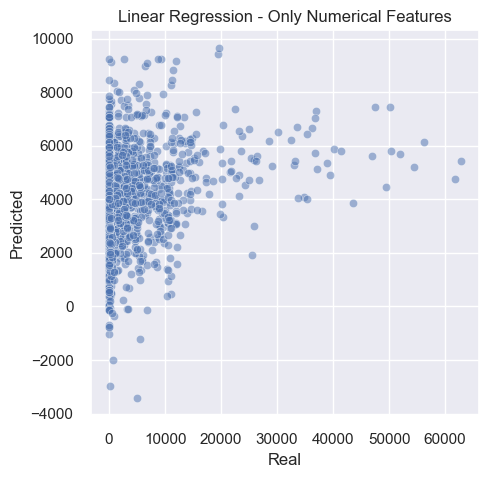

In [6]:
from sklearn.linear_model import LinearRegression

train = data[data['year'] < min(backtestings_years)].copy()
test  = data[data['year'].isin(backtestings_years)].copy()

columns_train = [col for col in train.columns if train[col].dtype != 'object']

X_train = train[columns_train].drop(columns=[target])
y_train = train[target]

X_test = test[columns_train].drop(columns=[target])
y_test = test[target]

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

df1 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Linear Regression - Only Numerical Features')
plot_predictions(y_test, y_pred_test, title='Linear Regression - Only Numerical Features')

#### Linear Regression - All dummies - Only Numerical Features

MAE Train: 1518.98
R2 Train: 0.81
MAE Test: 1861.61
R2 Test: 0.72


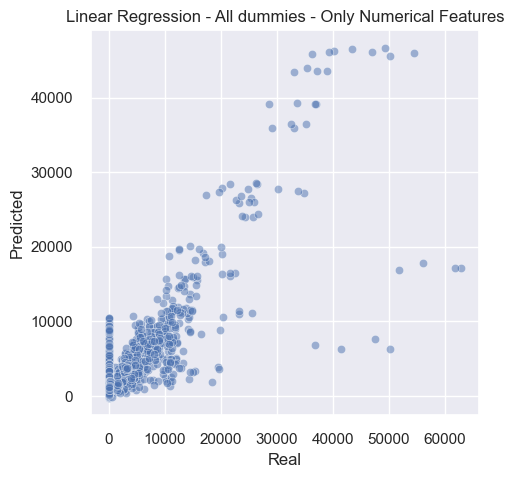

In [7]:
from sklearn.linear_model import LinearRegression

data_dummies = pd.get_dummies(data[['province','country']]) * 1

_data = pd.concat([data, data_dummies], axis=1).drop(columns=['province','country'])

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

columns_train = [col for col in train.columns if train[col].dtype != 'object']

X_train = train[columns_train].drop(columns=[target])
y_train = train[target]

X_test = test[columns_train].drop(columns=[target])
y_test = test[target]

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train = lr.predict(X_train)
y_pred_test  = lr.predict(X_test)

df2 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Linear Regression - All dummies - Only Numerical Features')
plot_predictions(y_test, y_pred_test, title='Linear Regression - All dummies - Only Numerical Features')

In [8]:
# Create a dataframe with the column names and their coefficients.
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})
coef_df

,Feature,Coefficient
0,year,98.319519
1,t2m_M1,-15.800454
2,t2m_M2,19.170263
3,t2m_M3,13.934852
4,t2m_M4,215.850416
...,...,...
501,country_spain,2572.671828
502,country_sweden,-1673.882879
503,country_switzerland,787.485743
504,country_türkiye,6373.223902


#### Random Forest - All dummies - no optimization

MAE Train: 387.82
R2 Train: 0.98
MAE Test: 1436.53
R2 Test: 0.81


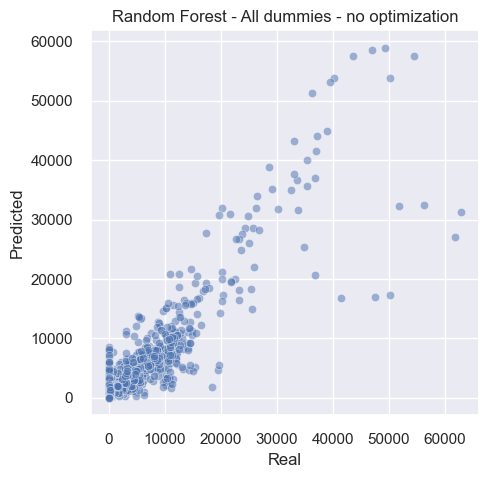

In [9]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

data_dummies = pd.get_dummies(data[['province','country']]) * 1

_data = pd.concat([data, data_dummies], axis=1).drop(columns=['province','country'])

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

columns_train = [col for col in train.columns if train[col].dtype != 'object']

X_train = train[columns_train].drop(columns=[target])
y_train = train[target]

X_test = test[columns_train].drop(columns=[target])
y_test = test[target]

model = RandomForestRegressor(random_state=random_state)
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

df3 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Random Forest - All dummies - no optimization')
plot_predictions(y_test, y_pred_test, title='Random Forest - All dummies - no optimization')

In [10]:
# Create a dataframe with importance of each feature
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})
variables = coef_df.sort_values('Importance', ascending=False).head(60).reset_index(drop=True)
variables_selected = variables['Feature'].tolist()

variables


,Feature,Importance
0,province_pays de la loire,0.095036
1,province_bretagne,0.094702
2,province_picardie,0.088481
3,year,0.083585
4,province_centre — val de loire,0.067373
5,province_champagne-ardenne,0.055726
6,province_poitou-charentes,0.032788
7,province_midi-pyrénées,0.031912
8,province_nord-pas de calais,0.029814
9,province_castilla y león,0.028652


#### Random Forest - Selected first 60 variables from importance - no optimization

MAE Train: 741.91
R2 Train: 0.95
MAE Test: 2065.50
R2 Test: 0.76


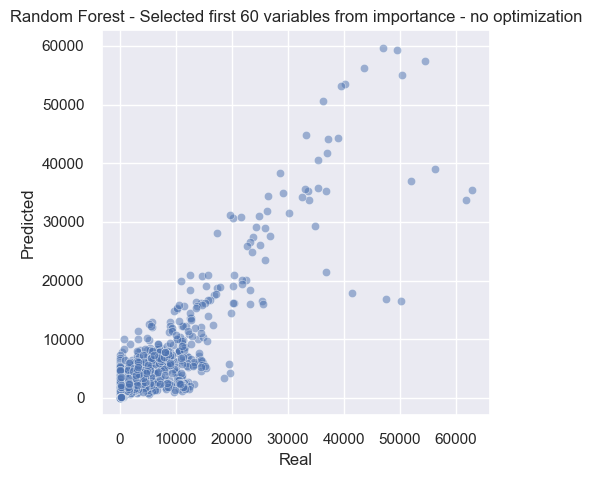

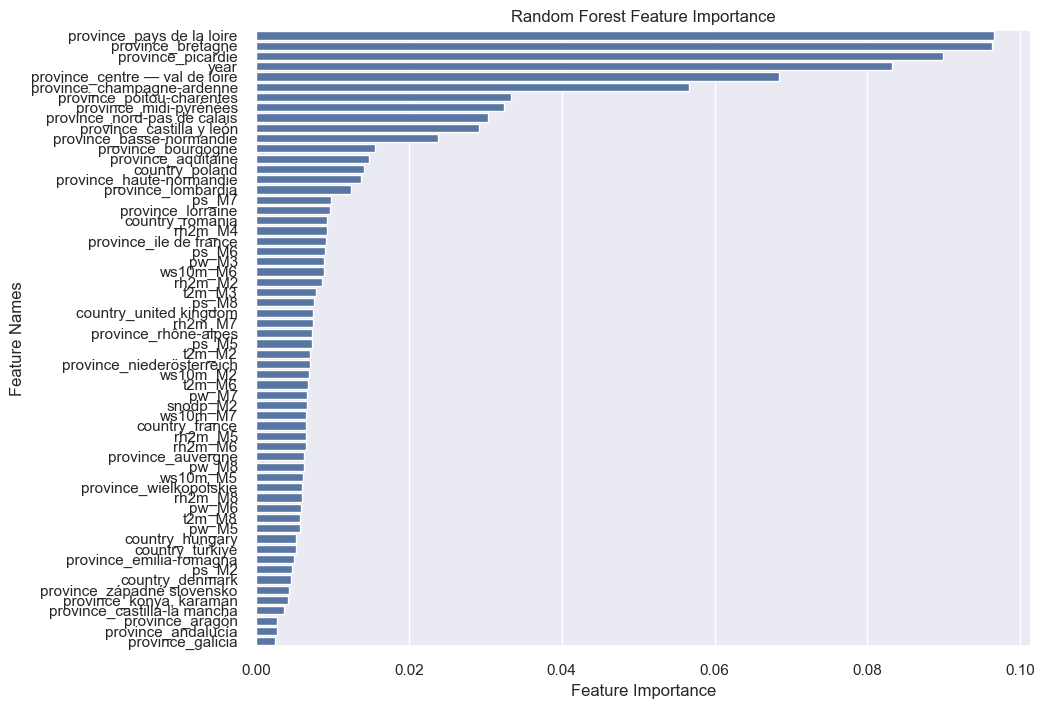

In [11]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

data_dummies = pd.get_dummies(data[['province','country']]) * 1

_data = pd.concat([data, data_dummies], axis=1).drop(columns=['province','country'])

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

X_train = train[variables_selected].copy()
y_train = train[target]

X_test = test[variables_selected].copy()
y_test = test[target]

model = RandomForestRegressor(random_state=random_state)    
model.fit(X_train, y_train)

y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

df4 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Random Forest - Selected first 60 variables from importance - no optimization')
plot_predictions(y_test, y_pred_test, title='Random Forest - Selected first 60 variables from importance - no optimization')
plot_feature_importance(model.feature_importances_, X_train.columns, 'Random Forest')

#### Random Forest - Selected first 60 variables from importance - Optimized

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

data_dummies = pd.get_dummies(data[['province','country']]) * 1

_data = pd.concat([data, data_dummies], axis=1).drop(columns=['province','country'])

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

X_train = train[variables_selected].copy()
y_train = train[target]

X_test = test[variables_selected].copy()
y_test = test[target]

rf = RandomForestRegressor(random_state=random_state)

param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, 30, 50, None],
    'min_samples_split': [2, 5, 10],
}

grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=21), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, 50, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 500]},
             scoring='neg_mean_squared_error')

In [13]:
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}


Mejores parámetros: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}

MAE Train: 1953.87
R2 Train: 0.81
MAE Test: 2503.54
R2 Test: 0.64


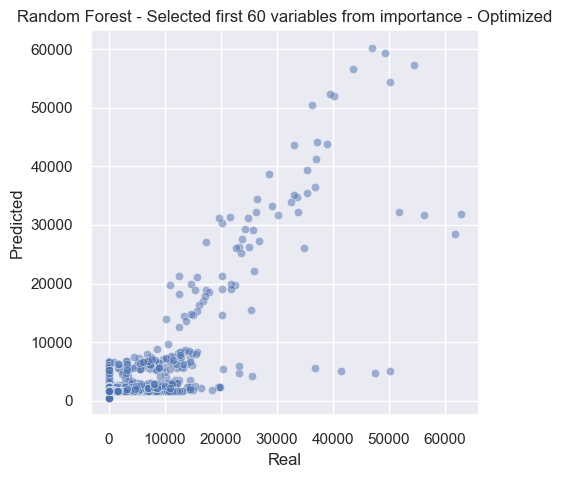

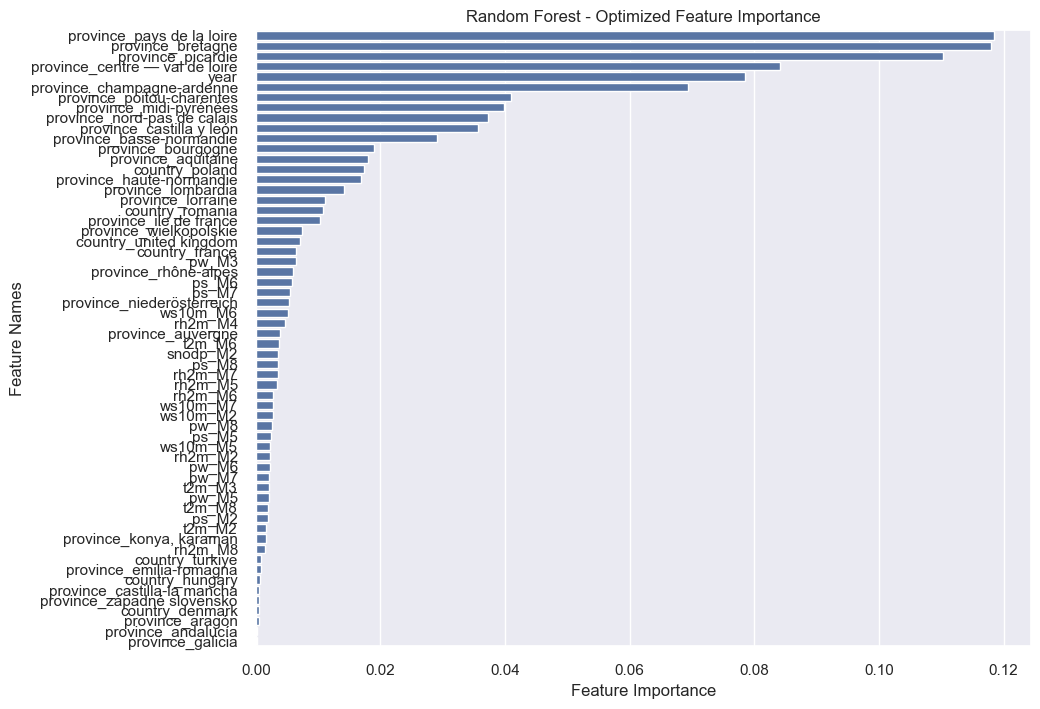

In [14]:
best_model = grid_search.best_estimator_

y_pred_train = best_model.predict(X_train)
y_pred_test  = best_model.predict(X_test)

df5 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='Random Forest - Selected first 60 variables from importance - Optimized')
plot_predictions(y_test, y_pred_test, title='Random Forest - Selected first 60 variables from importance - Optimized')
plot_feature_importance(best_model.feature_importances_, X_train.columns, 'Random Forest - Optimized')

Como se puede observar, no se ha mejorado en esta ronda de optimización, por lo que para no estar buscando aun más a detalle y seleccionar solo en base a importancia, usaremos una biblioteca/algoritmo que puede manejar mejor este tipo de variables y usará algoritmos de boosting.

#### LightGBM not Optimized

In [15]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder

_data = data.copy()

categorical_cols = ['province', 'country']
categorical_proccess = dict()

for col in categorical_cols:
    le = LabelEncoder()
    _data[col] = le.fit_transform(_data[col])
    categorical_proccess[col] = le

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

X_train = train.drop(columns=[target, 'code'])
y_train = train[target]

X_test = test.drop(columns=[target, 'code'])
y_test = test[target]


categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]


# Crear el modelo
model = lgb.LGBMRegressor(random_state=random_state,
                          categorical_features=categorical_features,
                          verbosity=1  )

# Entrenar el modelo
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],  # Evaluar en entrenamiento y test
    eval_metric='mae', 
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
    ]                                   # Mostrar progreso
)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12324
[LightGBM] [Info] Number of data points in the train set: 7847, number of used features: 59
[LightGBM] [Info] Start training from score 2961.499186
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[81]	training's l1: 491.767	training's l2: 881775	valid_1's l1: 1130.6	valid_1's l2: 7.59897e+06


LGBMRegressor(categorical_features=[0, 1], random_state=21, verbosity=1)

In [16]:
model.get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': 21,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0,
 'categorical_features': [0, 1],
 'verbosity': 1}

MAE Train: 491.77
R2 Train: 0.98
MAE Test: 1130.60
R2 Test: 0.85


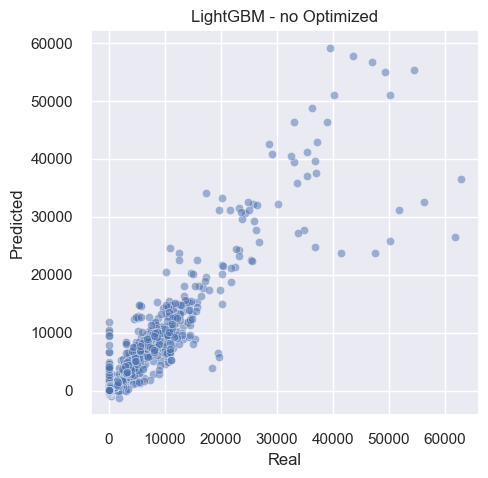

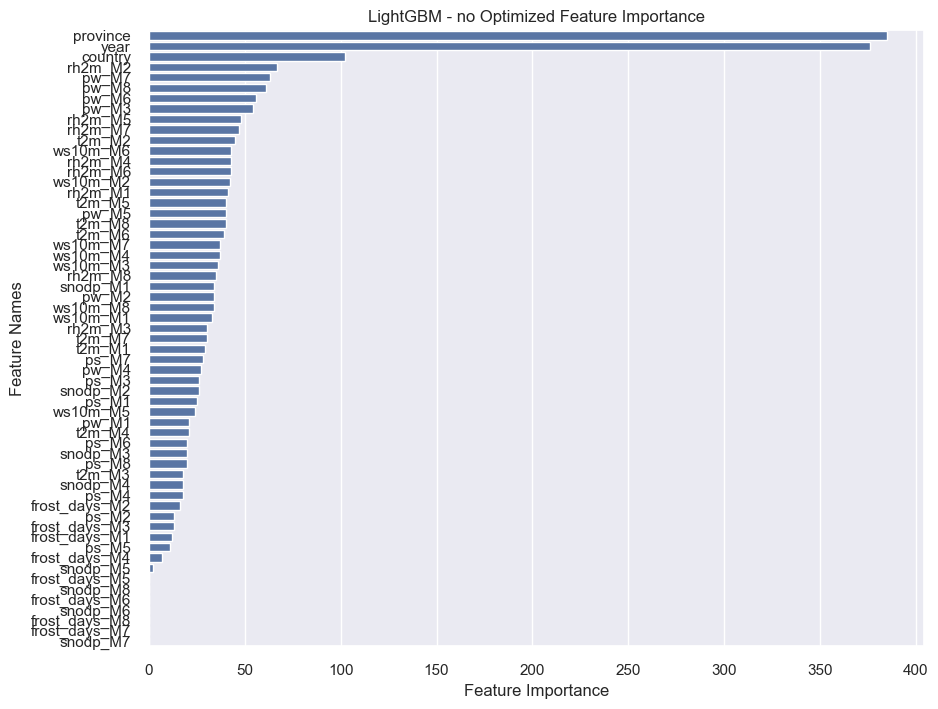

In [17]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

df6 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='LightGBM - no Optimized')
plot_predictions(y_test, y_pred_test, title='LightGBM - no Optimized')
plot_feature_importance(model.feature_importances_, X_train.columns, 'LightGBM - no Optimized')

#### LightGBM - Optimized

In [18]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

_data = data.copy()

categorical_cols = ['province', 'country']
categorical_proccess = dict()

for col in categorical_cols:
    le = LabelEncoder()
    _data[col] = le.fit_transform(_data[col])
    categorical_proccess[col] = le

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

X_train = train.drop(columns=[target, 'code'])
y_train = train[target]

X_test = test.drop(columns=[target, 'code'])
y_test = test[target]


categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]

# Definir el modelo base
model = lgb.LGBMRegressor(random_state=random_state,
                          categorical_features=categorical_features,
                          verbosity=1  )

# Espacio de hiperparámetros
param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

# Configurar RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_distributions,
    n_iter=500,                                 # Número de combinaciones a probar
    scoring='neg_mean_absolute_error',         # Métrica a optimizar
    cv=5,                                      # Número de folds para validación cruzada
    verbose=2,                                 # Nivel de detalle en la salida
    random_state=random_state,
    n_jobs=-1                                  # Usar todos los núcleos disponibles
)


random_search.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],               # Conjunto de validación
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
    ]      
)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12324
[LightGBM] [Info] Number of data points in the train set: 7847, number of used features: 59
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Start training from score 2961.499186
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[80]	valid_0's l1: 1253.68	valid_0's l2: 1.0361e+07


RandomizedSearchCV(cv=5,
                   estimator=LGBMRegressor(categorical_features=[0, 1],
                                           random_state=21, verbosity=1),
                   n_iter=500, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000028F6913F730>,
                                        'max_depth': [-1, 10, 20, 30, 40, 50,
                                                      100, 150],
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discret...
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028F6887F790>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028F68A0CAF0>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028F67F636A0>},
                   random_state=21, scoring='neg_mean_absolute_error',
                   verbose=2)

In [19]:
print("Mejores parámetros encontrados:", random_search.best_params_)


Mejores parámetros encontrados: {'learning_rate': 0.09528438076510458, 'max_depth': 40, 'min_child_samples': 5, 'min_samples_split': 74, 'n_estimators': 151, 'num_leaves': 24}


[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
MAE Train: 573.34
R2 Train: 0.97
MAE Test: 1253.68
R2 Test: 0.79


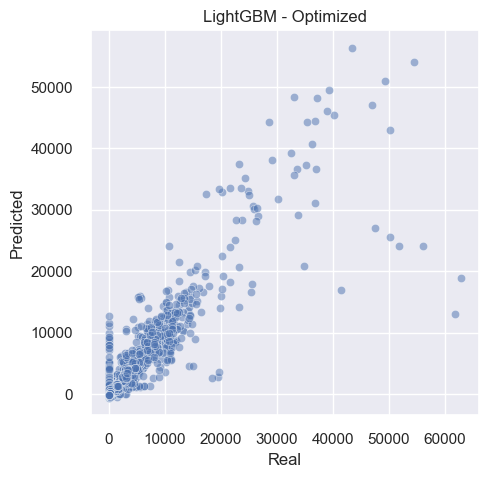

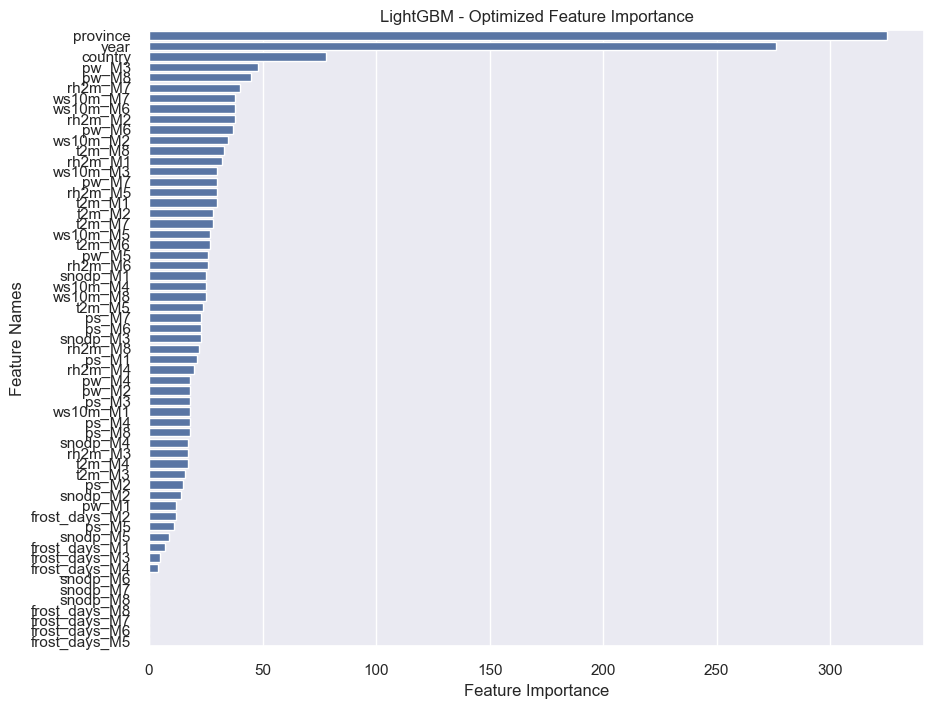

In [20]:
best_model_lgbm = random_search.best_estimator_

y_pred_train = best_model_lgbm.predict(X_train)
y_pred_test = best_model_lgbm.predict(X_test)

df7 = evaluate_metrics(y_train, y_pred_train, y_test, y_pred_test, title='LightGBM - Optimized')
plot_predictions(y_test, y_pred_test, title='LightGBM - Optimized')
plot_feature_importance(best_model_lgbm.feature_importances_, X_train.columns, 'LightGBM - Optimized')

#### LightGBM - Transformed Target - Optimized

In [21]:
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

_data = data.copy()

categorical_cols = ['province', 'country']
categorical_proccess = dict()

for col in categorical_cols:
    le = LabelEncoder()
    _data[col] = le.fit_transform(_data[col])
    categorical_proccess[col] = le

train = _data[_data['year'] < min(backtestings_years)].copy()
test  = _data[_data['year'].isin(backtestings_years)].copy()

X_train = train.drop(columns=[target, 'code'])
y_train = np.log(train[target]+1)

X_test = test.drop(columns=[target, 'code'])
y_test = np.log(test[target]+1)


categorical_features = [X_train.columns.get_loc(col) for col in categorical_cols]

# Definir el modelo base
model2 = lgb.LGBMRegressor(random_state=random_state,
                          categorical_features=categorical_features,
                          verbosity=1  )

# Espacio de hiperparámetros
param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

# Configurar RandomizedSearchCV
random_search2 = RandomizedSearchCV(
    estimator=model2,
    param_distributions=param_distributions,
    n_iter=500,                                 # Número de combinaciones a probar
    scoring='neg_mean_absolute_error',         # Métrica a optimizar
    cv=5,                                      # Número de folds para validación cruzada
    verbose=2,                                 # Nivel de detalle en la salida
    random_state=random_state,
    n_jobs=-1                                  # Usar todos los núcleos disponibles
)


random_search2.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],               # Conjunto de validación
    eval_metric='mae',
    callbacks=[
        lgb.early_stopping(stopping_rounds=10),
    ]      
)

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004118 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12324
[LightGBM] [Info] Number of data points in the train set: 7847, number of used features: 59
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Start training from score 4.016400
Training until validation scores don't improve for 10 rounds
Early stopping, best iteration is:
[81]	valid_0's l1: 0.851997	valid_0's l2: 2.40022


RandomizedSearchCV(cv=5,
                   estimator=LGBMRegressor(categorical_features=[0, 1],
                                           random_state=21, verbosity=1),
                   n_iter=500, n_jobs=-1,
                   param_distributions={'learning_rate': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x0000028F6A342020>,
                                        'max_depth': [-1, 10, 20, 30, 40, 50,
                                                      100, 150],
                                        'min_child_samples': <scipy.stats._distn_infrastructure.rv_discret...
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028F6A340040>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028F67E02B30>,
                                        'num_leaves': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000028F6A340610>},
                   random_state=21, scoring='neg_mean_absolute_error',
                   verbose=2)

In [22]:
print("Mejores parámetros encontrados:", random_search2.best_params_)

Mejores parámetros encontrados: {'learning_rate': 0.13147123900038715, 'max_depth': 20, 'min_child_samples': 14, 'min_samples_split': 10, 'n_estimators': 840, 'num_leaves': 49}


[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] Unknown parameter: min_samples_split
MAE Train: 616.99
R2 Train: 0.93
MAE Test: 1617.58
R2 Test: 0.58


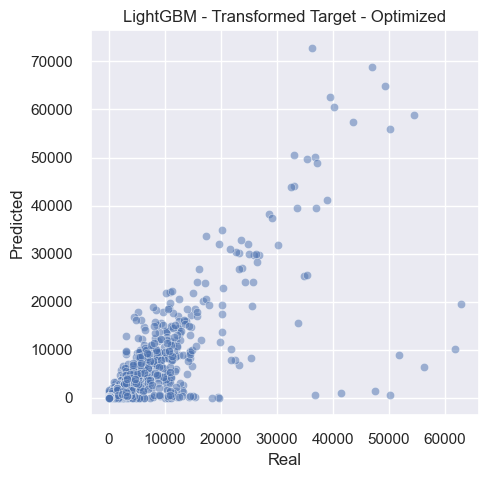

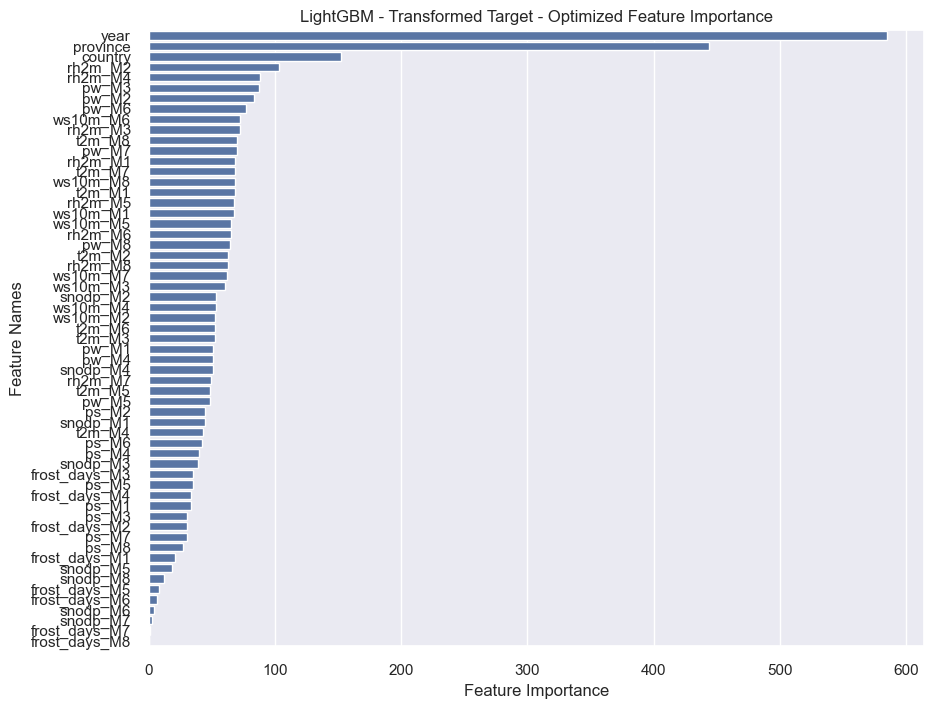

In [26]:
best_model_lgbm2 = random_search2.best_estimator_

y_pred_train = best_model_lgbm2.predict(X_train)
y_pred_test = best_model_lgbm2.predict(X_test)

df8 = evaluate_metrics(np.exp(y_train)-1, np.exp(y_pred_train)-1, np.exp(y_test)-1, np.exp(y_pred_test)-1, title='LightGBM - Transformed Target - Optimized')
plot_predictions(np.exp(y_test)-1, np.exp(y_pred_test)-1, title='LightGBM - Transformed Target - Optimized')
plot_feature_importance(best_model_lgbm2.feature_importances_, X_train.columns, 'LightGBM - Transformed Target - Optimized')

#### Basis Models Results

In [25]:
pd.concat([df1, df2, df3, df4, df5, df6, df7, df8],ignore_index=True)

,model_name,mae_train,r2_train,mae_test,r2_test
0,Linear Regression - Only Numerical Features,3593.468415,0.058162,4496.156733,0.029200
1,Linear Regression - All dummies - Only Numeric...,1518.983445,0.807218,1861.610607,0.717708
2,Random Forest - All dummies - no optimization,387.823807,0.981312,1436.526910,0.812481
3,Random Forest - Selected first 60 variables fr...,741.912760,0.954998,2065.503807,0.761859
4,Random Forest - Selected first 60 variables fr...,1953.865350,0.810731,2503.543867,0.643648
5,LightGBM - no Optimized,491.767213,0.980328,1130.603267,0.847888
6,LightGBM - Optimized,573.338409,0.974873,1253.680219,0.792599
7,LightGBM - Transformed Target - Optimized,616.993373,0.930817,1617.575349,0.581242


As we can see, LIGHTGBM Not Optimized in mes test is the best.

### PyCaret for Basis

#### Initial Setup

In [58]:
train = data[data['year'] < min(backtestings_years)].copy()
test  = data[data['year'].isin(backtestings_years)].copy()

In [59]:
from pycaret.regression import *
s = setup(data = train, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['code'],
          categorical_features = ['province','country'])

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(7847, 61)"
4,Transformed data shape,"(7847, 60)"
5,Transformed train set shape,"(5492, 60)"
6,Transformed test set shape,"(2355, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


In [60]:
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,1036.6507,6588926.6393,2551.1929,0.8401,3.1920,1.1647,0.3640
lightgbm,Light Gradient Boosting Machine,1117.2786,6541368.7087,2537.2690,0.8398,3.7249,1.5537,0.1660
rf,Random Forest Regressor,1099.2265,6922232.3772,2616.1352,0.8310,3.2452,1.3315,1.2040
gbr,Gradient Boosting Regressor,1313.8970,8069433.8529,2826.4884,0.8044,4.0082,2.4245,0.7690
knn,K Neighbors Regressor,1326.6673,9883656.1500,3135.3405,0.7590,2.8501,0.5260,0.0350
en,Elastic Net,1654.8738,11323139.8092,3352.6327,0.7269,4.5458,4.8018,0.2860
lasso,Lasso Regression,1677.8631,11331087.2591,3354.1149,0.7266,4.5876,4.9546,0.3880
llar,Lasso Least Angle Regression,1677.5698,11331274.6051,3354.1314,0.7266,4.5873,4.9562,0.0240
ridge,Ridge Regression,1681.4411,11337127.2488,3355.0252,0.7265,4.5925,4.9524,0.3480
lr,Linear Regression,1682.0360,11337962.7750,3355.1520,0.7265,4.5937,4.9608,0.4350


#### LightGBM - PyCaret - Not Optimized

In [61]:
lightgbm_model = create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1078.1629,4805728.7705,2192.1972,0.9054,3.7595,2.1106
1,1178.6595,8375411.3631,2894.0303,0.7705,3.6714,1.5116
2,1158.9693,6660156.0677,2580.7278,0.8652,3.5572,1.6105
3,1184.1704,8224906.7198,2867.9098,0.7618,3.9623,2.0545
4,1127.2118,5373248.4743,2318.0268,0.8973,3.7139,1.2428
5,1167.1269,6811551.3299,2609.8949,0.8354,3.6800,1.4697
6,1071.4150,4468065.1597,2113.7798,0.8908,3.7626,1.8936
7,1042.9281,5411188.5548,2326.1962,0.8441,3.7645,1.9027
8,994.5481,5442229.1269,2332.8586,0.8641,3.6153,0.9116


In [62]:
predictions_train_lgbm = predict_model(lightgbm_model, data = train)
predictions_test_lgbm = predict_model(lightgbm_model, data = test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,727.3467,2665997.5640,1632.7883,0.9405,3.5541,1.8206


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1638.5463,13179655.0326,3630.3795,0.7362,3.7783,9.9617


MAE Train: 727.35
R2 Train: 0.94
MAE Test: 1638.55
R2 Test: 0.74


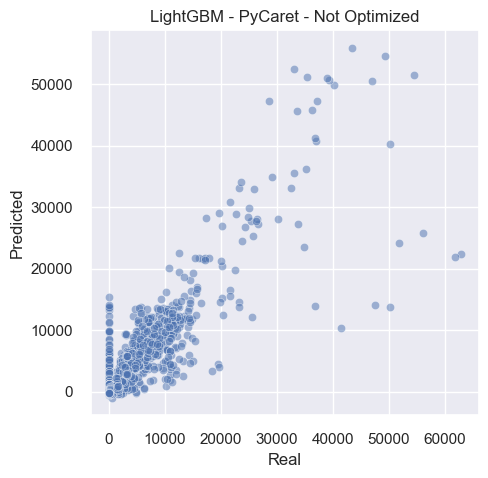

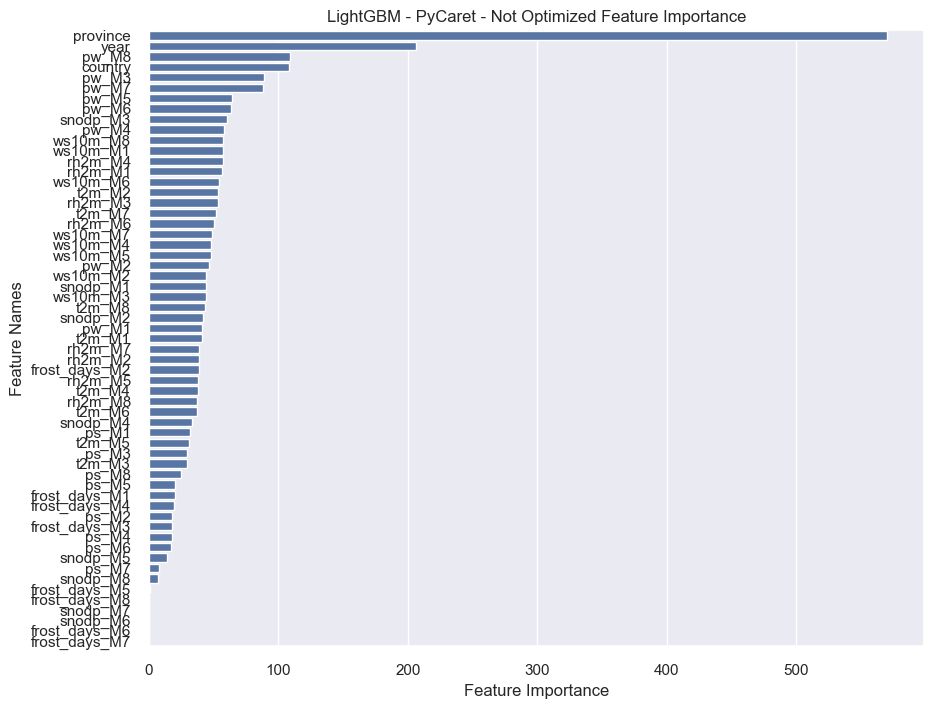

In [63]:
df9 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='LightGBM - PyCaret - Not Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='LightGBM - PyCaret - Not Optimized')
plot_feature_importance(lightgbm_model.feature_importances_, lightgbm_model.feature_names_in_, 'LightGBM - PyCaret - Not Optimized')

#### Random Forest - PyCaret - Not Optimized

In [64]:
rf_model = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1103.9247,6238177.8919,2497.6345,0.8772,3.2559,2.3155
1,1087.9201,8741084.7069,2956.5325,0.7605,3.1335,0.8385
2,1057.4093,5632553.6817,2373.3002,0.8860,3.0666,0.7109
3,1177.5791,8039807.9564,2835.4555,0.7672,3.4795,2.0020
4,1150.4669,6548945.0538,2559.0907,0.8748,3.2850,1.1046
5,1181.3410,7458911.1370,2731.1007,0.8198,3.1613,1.4703
6,1032.1756,4893169.7447,2212.0510,0.8804,3.3012,1.5640
7,1081.2772,6310771.2388,2512.1248,0.8181,3.2800,1.5584
8,963.9581,5480911.3760,2341.1346,0.8631,3.1222,0.7137


In [65]:
predictions_train_rf = predict_model(rf_model, data = train)
predictions_test_rf = predict_model(rf_model, data = test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,570.7749,2226819.5625,1492.2532,0.9503,2.6939,0.6764


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1410.3167,11852760.7885,3442.7839,0.7627,3.2527,2.0313


MAE Train: 570.77
R2 Train: 0.95
MAE Test: 1410.32
R2 Test: 0.76


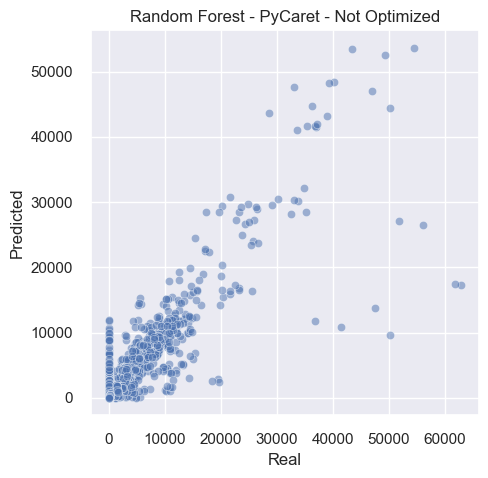

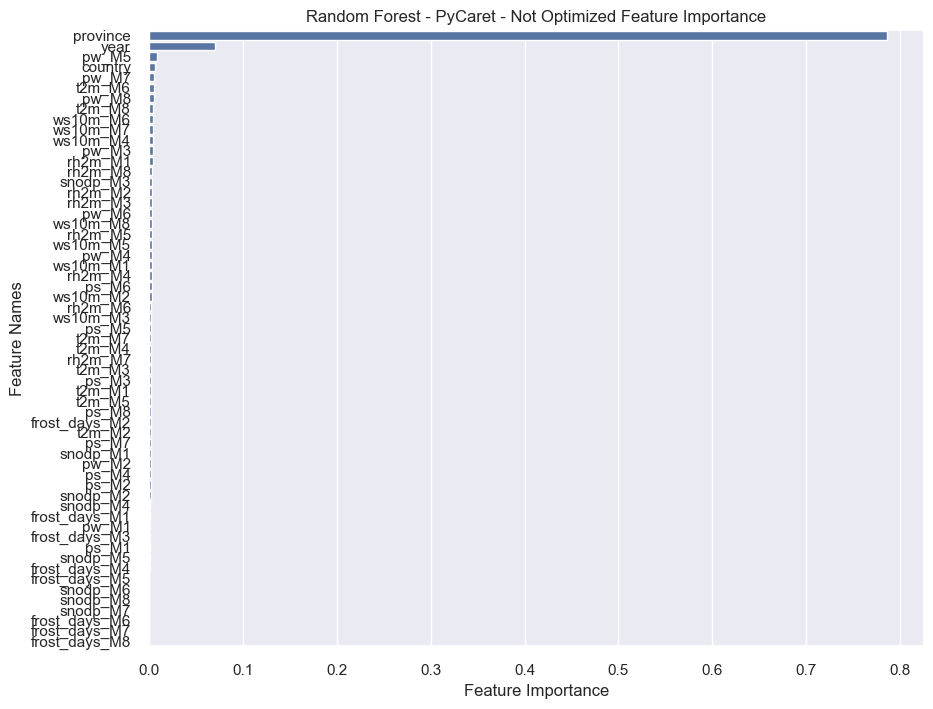

In [66]:
df10 = evaluate_metrics(predictions_train_rf['yield'], predictions_train_rf['prediction_label'], 
                       predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                       title='Random Forest - PyCaret - Not Optimized')
plot_predictions(predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                 title='Random Forest - PyCaret - Not Optimized')
plot_feature_importance(rf_model.feature_importances_, rf_model.feature_names_in_, 'Random Forest - PyCaret - Not Optimized')

#### Extra Trees - PyCaret - Not Optimized

In [67]:
et_model = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1054.1334,5383510.9117,2320.2394,0.8940,3.2195,1.5727
1,1022.9588,6973185.1486,2640.6789,0.8090,3.0329,1.0052
2,1047.8651,6227815.8081,2495.5592,0.8739,3.0809,0.5345
3,1097.3897,8751569.5528,2958.3052,0.7466,3.4227,2.2650
4,1104.0116,7347217.7781,2710.5752,0.8596,3.2518,0.5170
5,1086.8202,6988750.7753,2643.6246,0.8311,3.0634,1.5269
6,963.1180,4481648.6326,2116.9905,0.8905,3.2757,1.2006
7,972.1233,5118849.2203,2262.4874,0.8525,3.1841,1.3593
8,932.2345,5476432.2969,2340.1778,0.8632,3.1189,0.7498


In [68]:
predictions_train_et = predict_model(et_model, data = train)
predictions_test_et = predict_model(et_model, data = test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,299.4384,1691718.2256,1300.6607,0.9623,1.7223,0.2904


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,1297.2591,9593763.6002,3097.3801,0.8080,3.3723,1.4241


MAE Train: 299.44
R2 Train: 0.96
MAE Test: 1297.26
R2 Test: 0.81


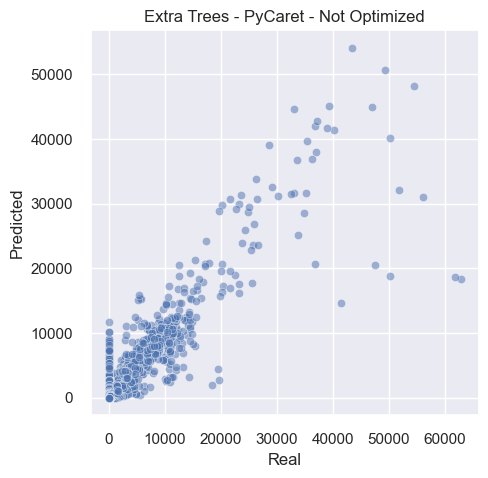

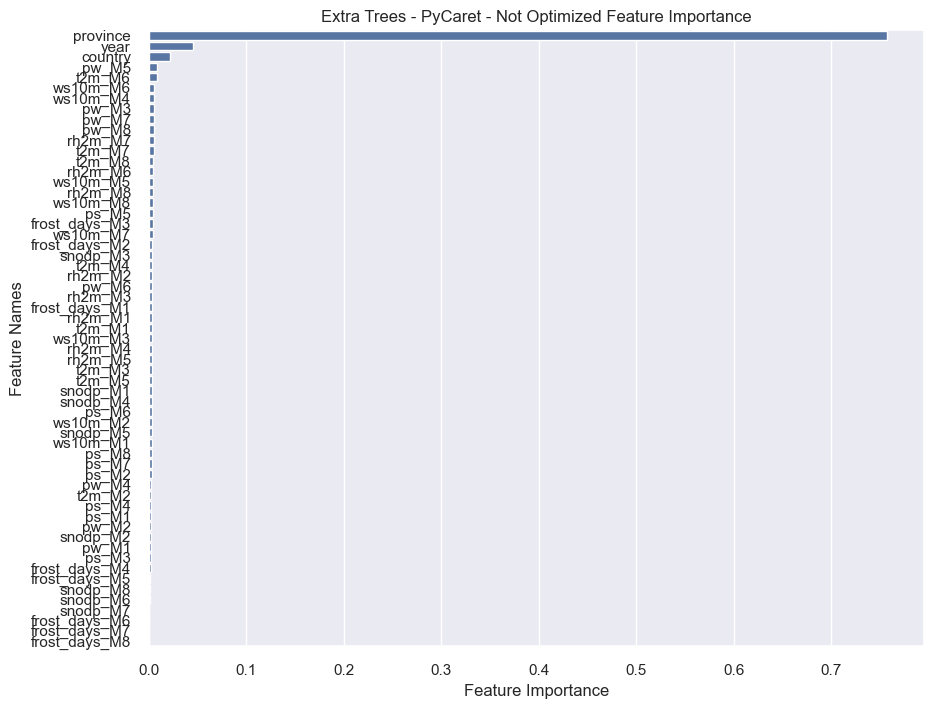

In [69]:
df11 = evaluate_metrics(predictions_train_et['yield'], predictions_train_et['prediction_label'], 
                       predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                       title='Extra Trees - PyCaret - Not Optimized')
plot_predictions(predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                 title='Extra Trees - PyCaret - Not Optimized')
plot_feature_importance(et_model.feature_importances_, et_model.feature_names_in_, 'Extra Trees - PyCaret - Not Optimized')

#### LightGBM - PyCaret - Optimized

In [74]:
lightgbm_model = create_model('lightgbm')

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

tuned_lgbm_model = tune_model(lightgbm_model, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1078.1629,4805728.7705,2192.1972,0.9054,3.7595,2.1106
1,1178.6595,8375411.3631,2894.0303,0.7705,3.6714,1.5116
2,1158.9693,6660156.0677,2580.7278,0.8652,3.5572,1.6105
3,1184.1704,8224906.7198,2867.9098,0.7618,3.9623,2.0545
4,1127.2118,5373248.4743,2318.0268,0.8973,3.7139,1.2428
5,1167.1269,6811551.3299,2609.8949,0.8354,3.6800,1.4697
6,1071.4150,4468065.1597,2113.7798,0.8908,3.7626,1.8936
7,1042.9281,5411188.5548,2326.1962,0.8441,3.7645,1.9027
8,994.5481,5442229.1269,2332.8586,0.8641,3.6153,0.9116


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1046.7233,5146337.1157,2268.5540,0.8987,3.4871,2.3870
1,1058.4306,8384004.5154,2895.5146,0.7703,3.4195,1.1421
2,1056.5238,6463892.5824,2542.4186,0.8692,3.4025,1.4072
3,1095.2424,8155038.0950,2855.7027,0.7638,3.7450,2.0794
4,1019.1758,4874820.2700,2207.8995,0.9068,3.5276,0.7761
5,1076.9641,6308244.6230,2511.6219,0.8476,3.4207,0.8498
6,1010.9685,4125682.4624,2031.1776,0.8992,3.5297,1.1462
7,1036.0082,6151271.4806,2480.1757,0.8227,3.5431,1.6309
8,928.2158,5680163.5359,2383.3094,0.8582,3.3996,1.1525


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [75]:
predictions_train_lgbm = predict_model(tuned_lgbm_model, data = train)
predictions_test_lgbm = predict_model(tuned_lgbm_model, data = test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,474.0905,1876168.7124,1369.7331,0.9581,3.1706,0.9729


[LightGBM] [Warning] Unknown parameter: min_samples_split


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1573.6459,12207164.2599,3493.8752,0.7556,3.7683,3.0473


[LightGBM] [Warning] Unknown parameter: min_samples_split


MAE Train: 474.09
R2 Train: 0.96
MAE Test: 1573.65
R2 Test: 0.76


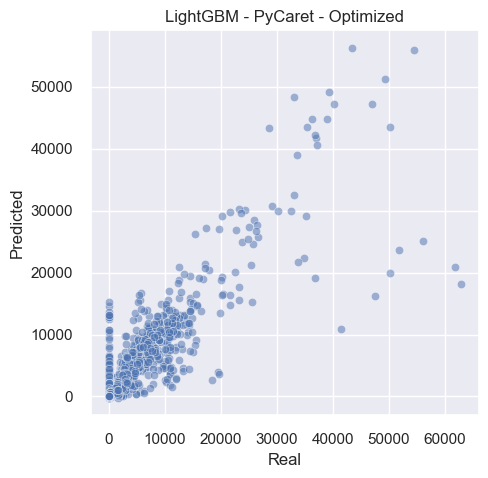

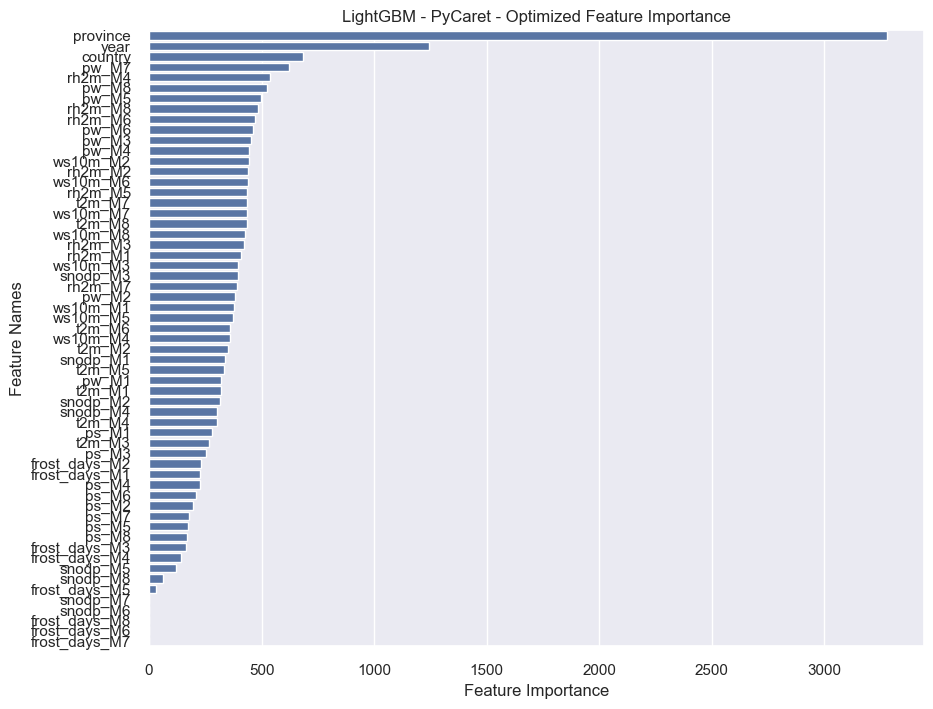

In [76]:
df12 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model.feature_importances_, tuned_lgbm_model.feature_names_in_, 'LightGBM - PyCaret - Optimized')

#### Random Forest - PyCaret - Optimized

In [80]:
rf_model = create_model('rf')

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

tuned_rf_model = tune_model(rf_model, n_iter = 50, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1103.9247,6238177.8919,2497.6345,0.8772,3.2559,2.3155
1,1087.9201,8741084.7069,2956.5325,0.7605,3.1335,0.8385
2,1057.4093,5632553.6817,2373.3002,0.8860,3.0666,0.7109
3,1177.5791,8039807.9564,2835.4555,0.7672,3.4795,2.0020
4,1150.4669,6548945.0538,2559.0907,0.8748,3.2850,1.1046
5,1181.3410,7458911.1370,2731.1007,0.8198,3.1613,1.4703
6,1032.1756,4893169.7447,2212.0510,0.8804,3.3012,1.5640
7,1081.2772,6310771.2388,2512.1248,0.8181,3.2800,1.5584
8,963.9581,5480911.3760,2341.1346,0.8631,3.1222,0.7137


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1107.5174,6002466.0451,2449.9931,0.8818,3.3130,2.1305
1,1073.1743,8693264.2669,2948.4342,0.7618,3.2002,1.4219
2,1040.4127,5454510.4804,2335.4893,0.8896,3.0951,0.7216
3,1185.8893,7999374.4654,2828.3165,0.7684,3.5376,1.7709
4,1134.4751,6278297.2369,2505.6531,0.8800,3.3568,1.1374
5,1194.7168,7543842.7052,2746.6057,0.8177,3.2257,1.8254
6,1043.9414,5073937.5835,2252.5403,0.8760,3.3584,1.6310
7,1077.1315,6223661.6726,2494.7268,0.8206,3.3431,1.7936
8,965.2811,5155060.4240,2270.4758,0.8713,3.2091,0.7284


Fitting 10 folds for each of 50 candidates, totalling 500 fits


In [81]:
predictions_train_rf = predict_model(tuned_rf_model, data = train)
predictions_test_rf = predict_model(tuned_rf_model, data = test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,608.6456,2467903.4201,1570.9562,0.9449,2.7997,0.7819


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,1415.2263,12073788.7493,3474.7358,0.7583,3.2789,2.1395


MAE Train: 608.65
R2 Train: 0.94
MAE Test: 1415.23
R2 Test: 0.76


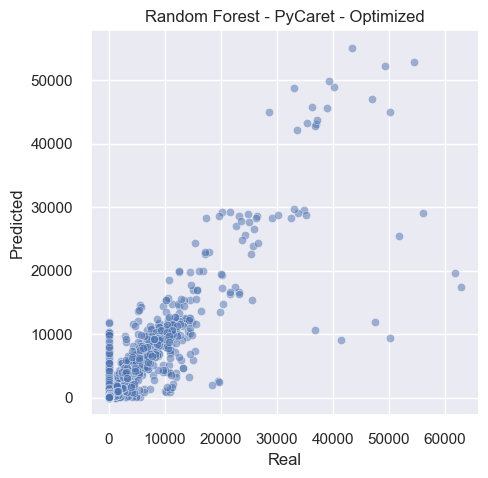

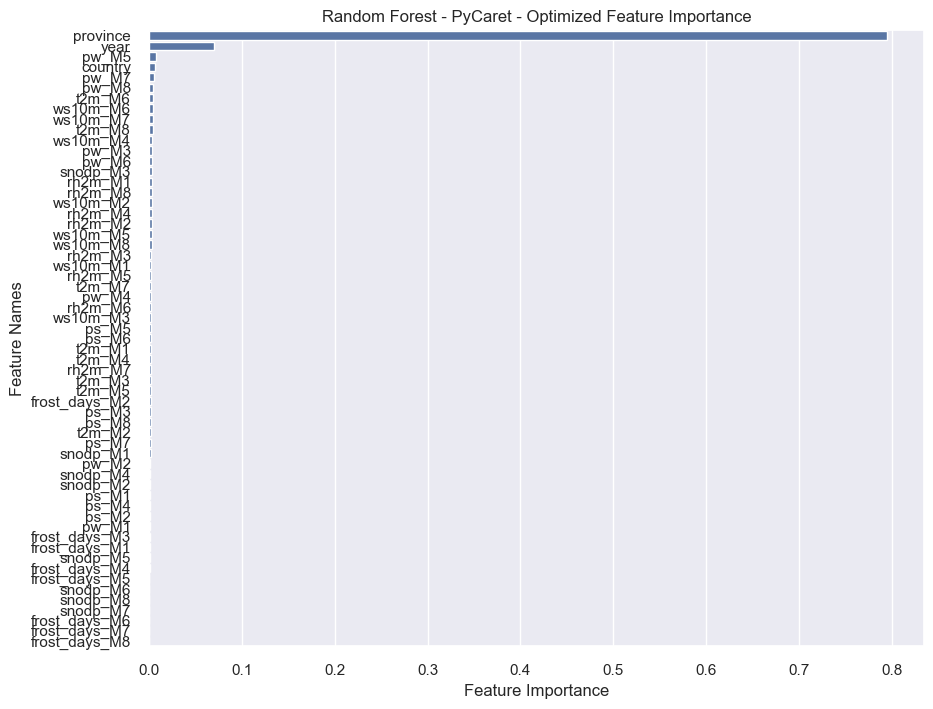

In [82]:
df13 = evaluate_metrics(predictions_train_rf['yield'], predictions_train_rf['prediction_label'], 
                       predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                       title='Random Forest - PyCaret - Optimized')
plot_predictions(predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                 title='Random Forest - PyCaret - Optimized')
plot_feature_importance(tuned_rf_model.feature_importances_, tuned_rf_model.feature_names_in_, 'Random Forest - PyCaret - Optimized')

#### Extra Trees - PyCaret - Optimized

In [83]:
et_model = create_model('et')

param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

tuned_et_model = tune_model(et_model, n_iter = 50, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1054.1334,5383510.9117,2320.2394,0.8940,3.2195,1.5727
1,1022.9588,6973185.1486,2640.6789,0.8090,3.0329,1.0052
2,1047.8651,6227815.8081,2495.5592,0.8739,3.0809,0.5345
3,1097.3897,8751569.5528,2958.3052,0.7466,3.4227,2.2650
4,1104.0116,7347217.7781,2710.5752,0.8596,3.2518,0.5170
5,1086.8202,6988750.7753,2643.6246,0.8311,3.0634,1.5269
6,963.1180,4481648.6326,2116.9905,0.8905,3.2757,1.2006
7,972.1233,5118849.2203,2262.4874,0.8525,3.1841,1.3593
8,932.2345,5476432.2969,2340.1778,0.8632,3.1189,0.7498


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1050.1739,5245953.5330,2290.4047,0.8967,3.2400,1.7952
1,1003.8774,6793362.4995,2606.4080,0.8139,3.1040,0.9518
2,1010.4269,5530870.9526,2351.7804,0.8880,3.1273,0.5383
3,1118.2630,9140667.5654,3023.3537,0.7353,3.4810,2.3328
4,1101.8194,7183116.3780,2680.1336,0.8627,3.2910,0.5712
5,1107.6259,7260403.0404,2694.5135,0.8246,3.1069,1.1909
6,967.7752,4519557.1754,2125.9250,0.8895,3.3584,1.3621
7,981.9988,5318244.0558,2306.1318,0.8467,3.2440,1.3533
8,918.0626,5261163.4773,2293.7226,0.8686,3.1408,0.6082


Fitting 10 folds for each of 50 candidates, totalling 500 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [84]:
predictions_train_et = predict_model(tuned_et_model, data = train)
predictions_test_et = predict_model(tuned_et_model, data = test)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,299.4384,1691718.2256,1300.6607,0.9623,1.7223,0.2904


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,1297.2591,9593763.6002,3097.3801,0.8080,3.3723,1.4241


MAE Train: 299.44
R2 Train: 0.96
MAE Test: 1297.26
R2 Test: 0.81


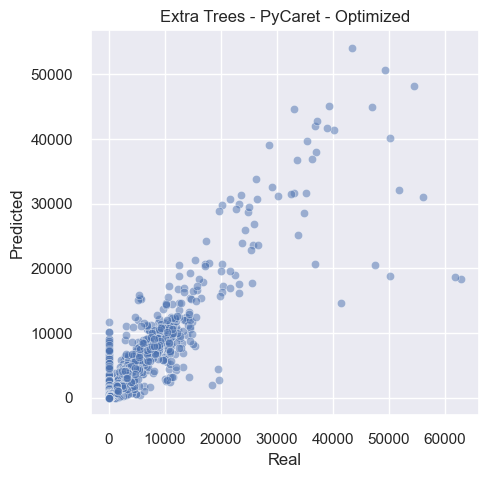

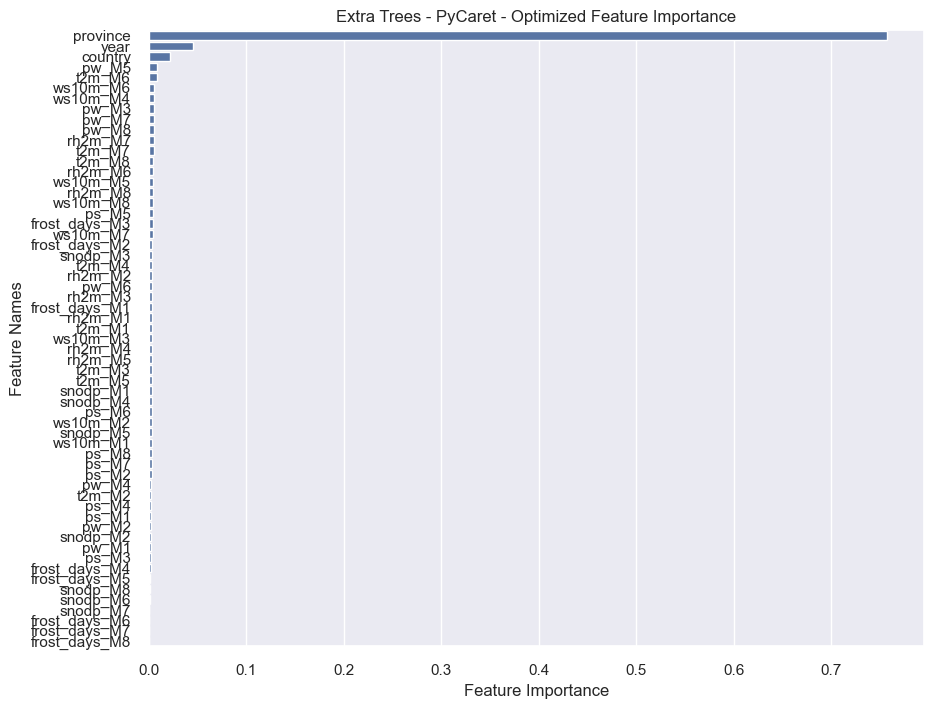

In [85]:
df14 = evaluate_metrics(predictions_train_et['yield'], predictions_train_et['prediction_label'], 
                       predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                       title='Extra Trees - PyCaret - Optimized')
plot_predictions(predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                 title='Extra Trees - PyCaret - Optimized')
plot_feature_importance(tuned_et_model.feature_importances_, tuned_et_model.feature_names_in_, 'Extra Trees - PyCaret - Optimized')

#### Conclusion Basis + Pycaret Models Results

In [88]:
df_basis_results = pd.concat([df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12, df13, df14], ignore_index=True)
df_basis_results.to_csv('../results/basic_model_formulation_results.csv', index=False)

In [89]:
df_basis_results

,model_name,mae_train,r2_train,mae_test,r2_test
0,Linear Regression - Only Numerical Features,3593.468415,0.058162,4496.156733,0.029200
1,Linear Regression - All dummies - Only Numeric...,1518.983445,0.807218,1861.610607,0.717708
2,Random Forest - All dummies - no optimization,387.823807,0.981312,1436.526910,0.812481
3,Random Forest - Selected first 60 variables fr...,741.912760,0.954998,2065.503807,0.761859
4,Random Forest - Selected first 60 variables fr...,1953.865350,0.810731,2503.543867,0.643648
5,LightGBM - no Optimized,491.767213,0.980328,1130.603267,0.847888
6,LightGBM - Optimized,573.338409,0.974873,1253.680219,0.792599
7,LightGBM - Transformed Target - Optimized,616.993373,0.930817,1617.575349,0.581242
8,LightGBM - PyCaret - Not Optimized,727.346695,0.940522,1638.546257,0.736177
9,Random Forest - PyCaret - Not Optimized,570.774907,0.950320,1410.316715,0.762738


As can be seen, the model that performs best is the non-optimized LightGBM, seeing that there is a certain percentage of overfitting in the training. Pycaret was used for ease of later implementation, but it was shown that a model can be made from scratch without needing to use that library. That is why it will be used in later models for ease of use and search. Most models are highly dependent on their province and country variables, which is understandable due to the different extractable yields, so in later models they are grouped to have more precise models, since countries that produce a lot can affect the error calculation of countries that produce less.

## COMPLEX MODEL FORMULATION

### Grouped by Yield decline by country

#### Info Setup

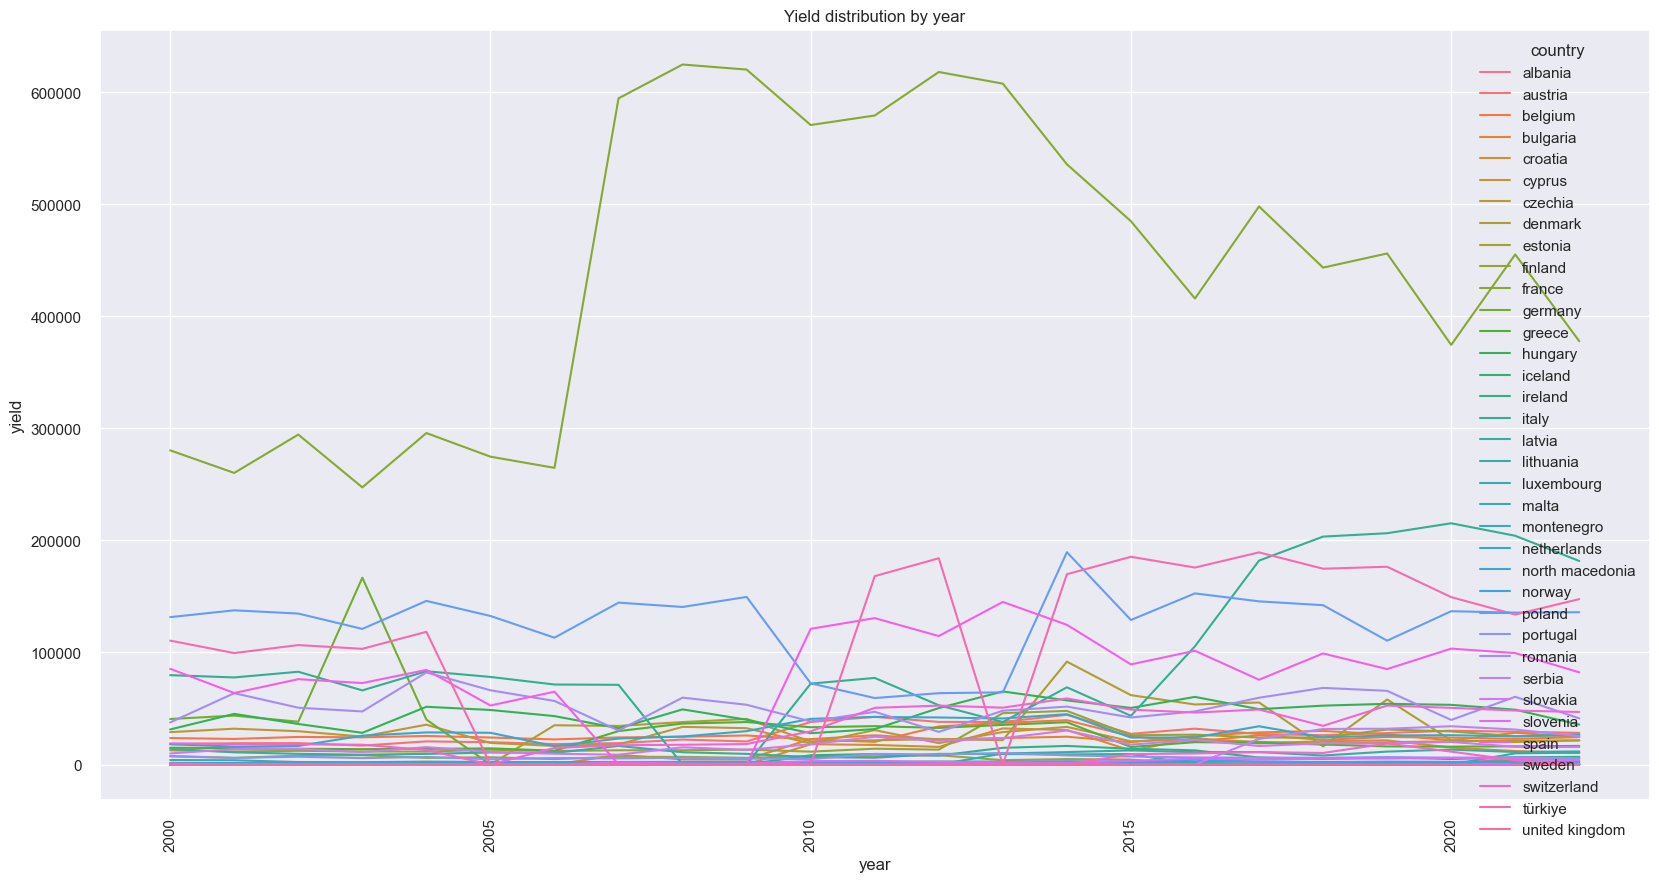

In [90]:
data_grouped = data.groupby(['country','year']).agg({'yield':'sum'}).reset_index()

plt.figure(figsize=(20, 10))
sns.lineplot(data=data_grouped, 
             x='year', y='yield', hue='country')
plt.title('Yield distribution by year')
plt.xticks(rotation=90)
plt.show()

In [99]:
df_res1 = data_grouped[data_grouped['year'].isin([2020,2021,2022])].groupby(['country']).agg({'yield':'mean'}).reset_index().sort_values(by='yield', ascending=False).head(10)
df_res1

,country,yield
10,france,402605.008963
16,italy,200410.436459
34,türkiye,143651.250089
25,poland,136127.223678
31,spain,95072.467131
32,sweden,48547.496794
27,romania,47136.100302
13,hungary,45952.636817
28,serbia,30226.743211
1,austria,29247.290011


As we can observe, there are 3 average yield declines over the last 3 years, which we can use to group the countries into 3 categories. France is in a group by itself, Italy, Turkey, Poland, and Spain are in another group, and the last group consists of the remaining countries. This allows us to have 3 different models based on the given Yield.

<Figure size 1000x500 with 0 Axes>

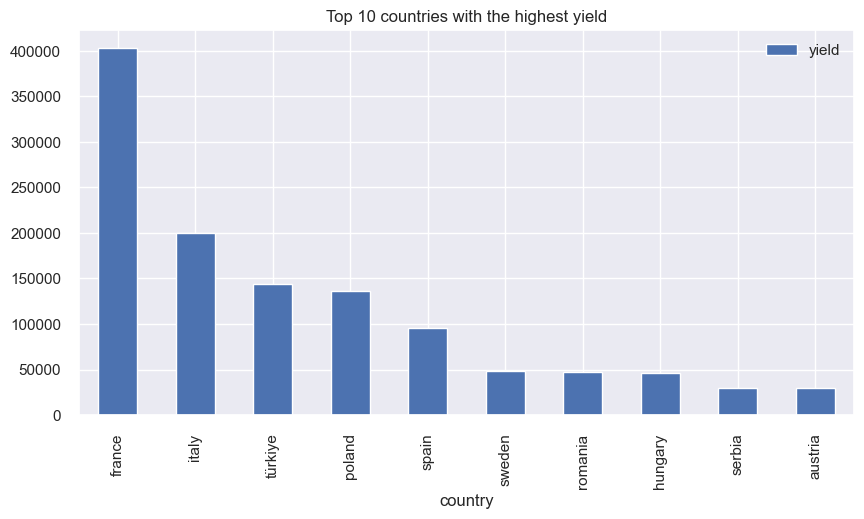

In [98]:
plt.figure(figsize=(10, 5))
df_res1.plot(kind='bar', x='country', y='yield', figsize=(10, 5))
plt.title('Top 10 countries with the highest yield')
plt.show()

In [100]:
df_group1 = data[data['country'].isin(['france'])].copy()
df_group2 = data[data['country'].isin(['italy','türkiye','poland','spain'])].copy()
df_group3 = data[~data['country'].isin(['france','italy','türkiye','poland','spain'])].copy()

#### Model for Group 1: France

In [161]:
df_group1.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
161,alsace,france,2000,5043.050096,-0.203548,3.715862,5.573226,10.336667,15.585161,18.512333,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,FR
162,alsace,france,2001,4384.899978,1.030323,2.884286,6.672903,7.575333,15.391290,15.985667,...,0.0,1.037097,1.018214,1.420968,1.252667,1.894194,1.867667,2.483226,2.460645,FR
163,alsace,france,2002,4844.620098,-0.361935,5.068929,6.697419,9.009000,13.733548,19.841333,...,0.0,0.932258,1.259643,1.119355,1.182000,1.800645,2.343000,2.428710,2.592581,FR
164,alsace,france,2003,4060.530132,-0.530968,-1.735714,6.658065,9.036000,15.160968,22.718333,...,0.0,0.913871,0.638929,1.016129,1.174333,1.932903,2.638333,2.361935,2.411290,FR
165,alsace,france,2004,4952.169952,0.444194,1.814828,4.355806,9.925667,13.031613,17.835333,...,0.0,1.015806,0.893103,0.974839,1.313000,1.400645,1.982333,2.314194,2.635161,FR


In [162]:
train_g1 = df_group1[df_group1['year'] < min(backtestings_years)].copy()
test_g1  = df_group1[df_group1['year'].isin(backtestings_years)].copy()

In [163]:
from pycaret.regression import *
s = setup(data = train_g1, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['code'],
          categorical_features = ['province','country'])

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(1083, 61)"
4,Transformed data shape,"(1083, 60)"
5,Transformed train set shape,"(758, 60)"
6,Transformed test set shape,"(325, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


In [164]:
lightgbm_model_g1 = create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,883.8750,3712070.1482,1926.6733,0.9792,3.3899,0.2021
1,1253.9437,6575624.6148,2564.2981,0.9629,3.4226,7.6015
2,1338.9840,10065307.4244,3172.5869,0.9376,3.1694,1.1380
3,745.3364,2392726.9731,1546.8442,0.9840,3.8408,3.7503
4,710.3570,2079796.3823,1442.1499,0.9837,3.9754,0.4904
5,1248.4761,7772379.9033,2787.8988,0.9615,3.8165,0.6091
6,1588.9254,10363920.5156,3219.3044,0.9643,3.4900,3.9403
7,1248.7158,6970231.0446,2640.1195,0.9618,3.7838,0.5411
8,1131.9661,4634920.5235,2152.8866,0.9813,3.4943,1.3382


In [165]:
predictions_train_lgbm = predict_model(lightgbm_model_g1, data = train_g1)
predictions_test_lgbm = predict_model(lightgbm_model_g1, data = test_g1)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,505.2513,1699051.5336,1303.4767,0.9914,3.2145,1.0822


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1289.3821,9677183.8767,3110.8172,0.9361,3.4607,2.7524


MAE Train: 505.25
R2 Train: 0.99
MAE Test: 1289.38
R2 Test: 0.94


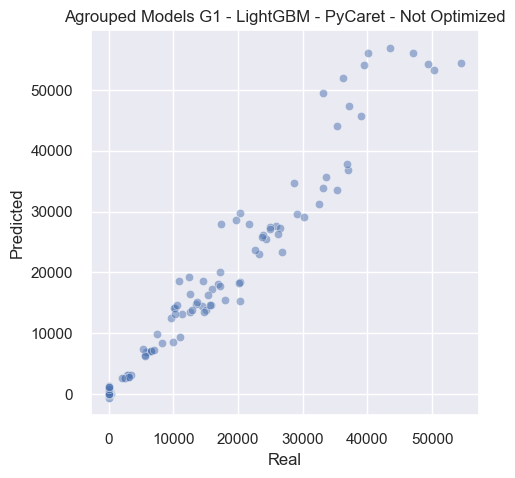

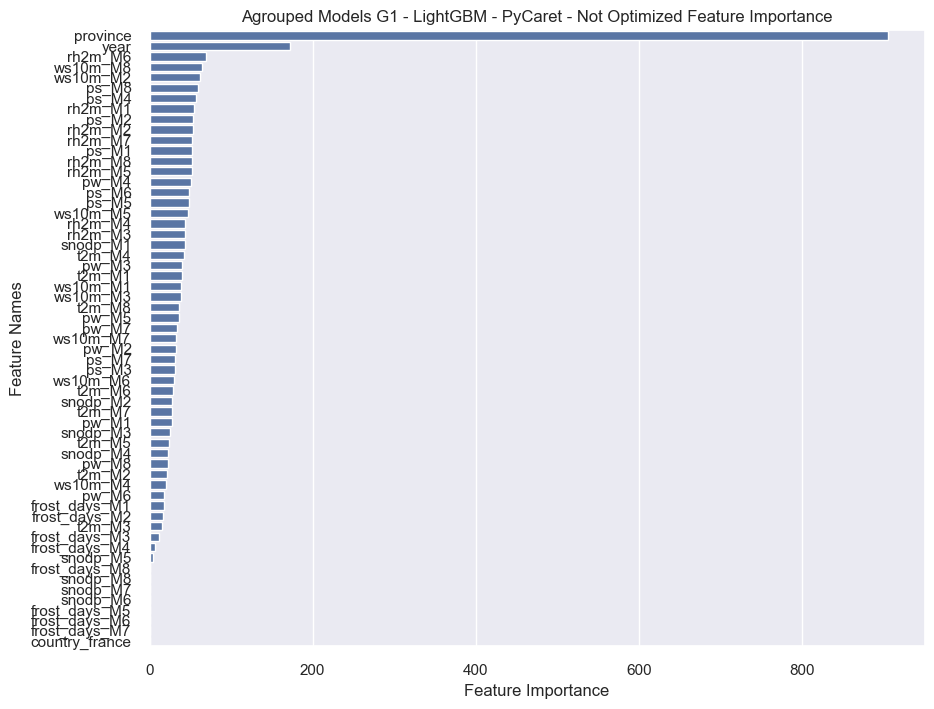

In [166]:
df1 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G1 - LightGBM - PyCaret - Not Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G1 - LightGBM - PyCaret - Not Optimized')
plot_feature_importance(lightgbm_model_g1.feature_importances_, lightgbm_model_g1.feature_names_in_, 'Agrouped Models G1 - LightGBM - PyCaret - Not Optimized')

In [167]:
param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

tuned_lgbm_model_g1 = tune_model(lightgbm_model_g1, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,609.0703,1875678.6734,1369.5542,0.9895,2.7206,0.1725
1,945.1192,4136599.8119,2033.8633,0.9766,2.4862,0.8939
2,888.3894,3167557.1897,1779.7632,0.9804,2.4475,0.7414
3,545.3152,1502657.1808,1225.8292,0.9899,2.9318,1.5289
4,684.3985,2485127.8177,1576.4288,0.9805,3.5125,0.2450
5,757.5532,2528507.5626,1590.1282,0.9875,3.0185,0.3338
6,1229.4048,5899748.1191,2428.9397,0.9797,3.0790,0.4642
7,687.2067,2462900.8552,1569.3632,0.9865,2.3931,0.4862
8,852.0141,2831594.9955,1682.7344,0.9886,2.5577,0.3203


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [168]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g1, data = train_g1)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g1, data = test_g1)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,222.0774,658144.3863,811.2610,0.9967,1.9806,0.3356


[LightGBM] [Warning] Unknown parameter: min_samples_split


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1275.0561,9238227.2616,3039.4452,0.9390,2.9747,2.1498


[LightGBM] [Warning] Unknown parameter: min_samples_split


MAE Train: 222.08
R2 Train: 1.00
MAE Test: 1275.06
R2 Test: 0.94


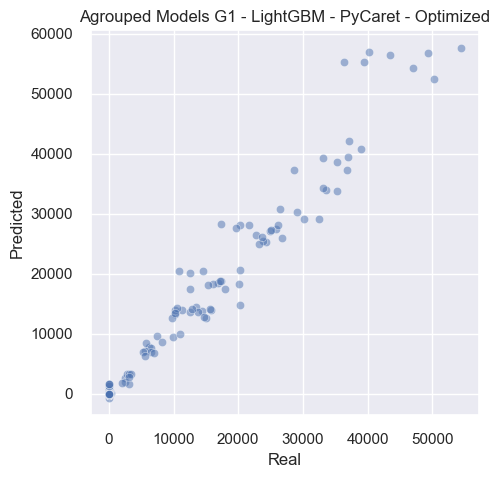

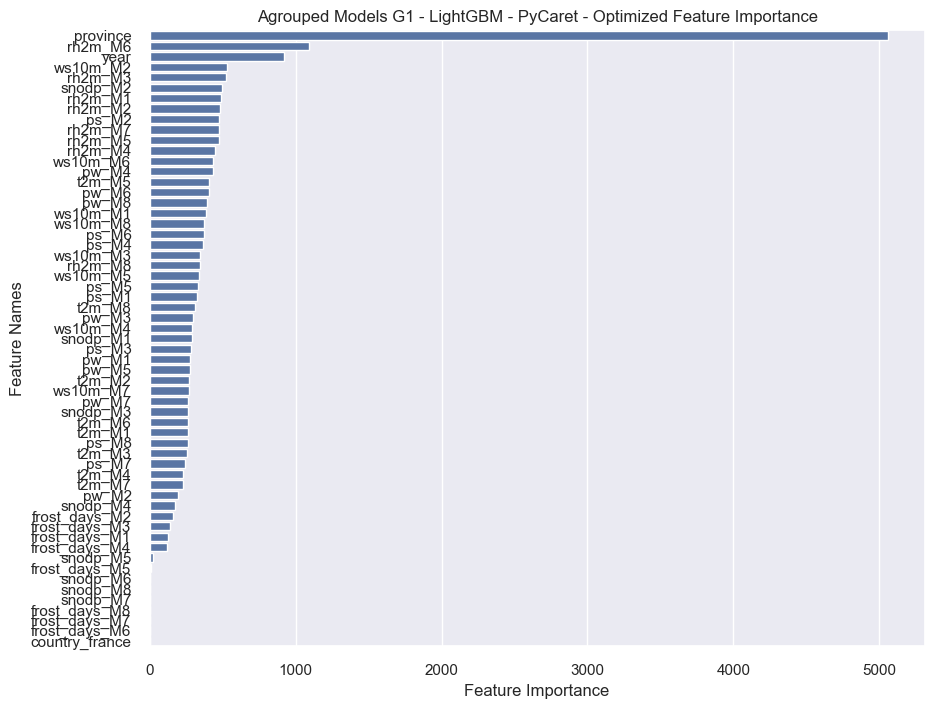

In [169]:
df2 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G1 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g1.feature_importances_, tuned_lgbm_model_g1.feature_names_in_, 'Agrouped Models G1 - LightGBM - PyCaret - Optimized')

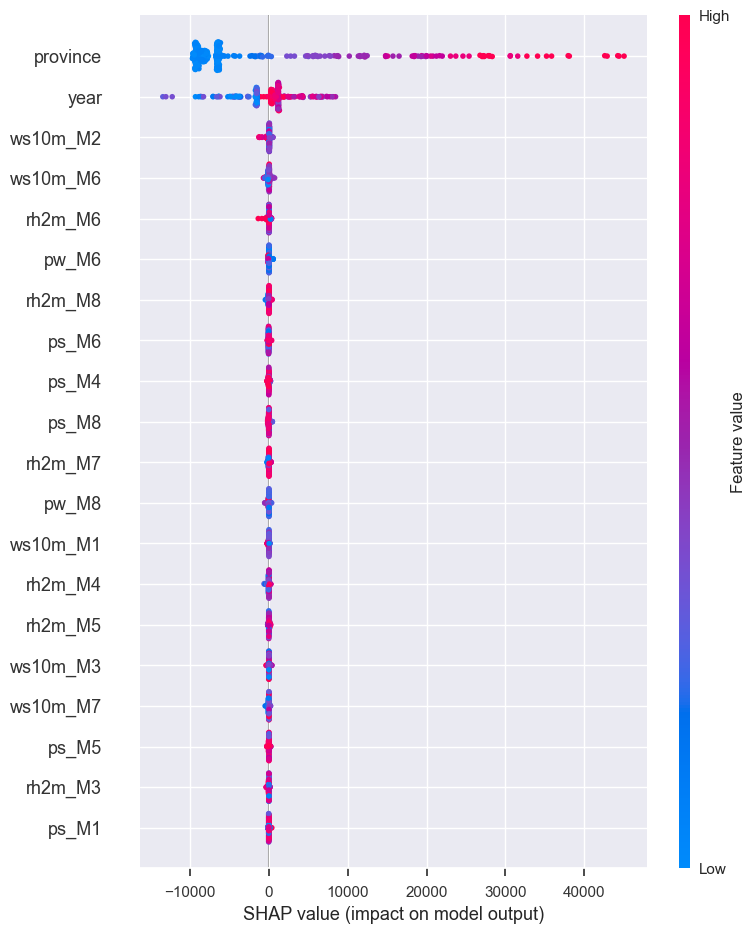

In [170]:
interpret_model(tuned_lgbm_model_g1)

#### Model for Group 2: Italy, Turkey, Poland and Spain

In [141]:
df_group2.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
0,abruzzo,italy,2000,1637.739987,-0.129677,1.588276,4.154839,8.701667,14.219355,17.828667,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,IT
1,abruzzo,italy,2001,1598.159992,2.929677,1.700000,7.197097,6.281333,13.248710,16.045000,...,0.0,1.164839,0.823214,1.299355,1.099667,1.762903,1.732333,2.071290,2.157097,IT
2,abruzzo,italy,2002,1595.639976,-0.383226,4.061786,5.908065,7.896667,13.072581,19.241000,...,0.0,0.733871,1.016429,0.975161,1.243000,1.688065,2.105000,2.331613,2.419677,IT
3,abruzzo,italy,2003,1340.019975,1.565806,-2.159643,3.962258,6.703333,15.211290,21.048333,...,0.0,0.940968,0.596071,0.842258,1.079000,1.736129,2.281333,2.144516,2.448065,IT
4,abruzzo,italy,2004,1496.790036,0.126129,2.306897,3.473548,7.638000,9.717097,16.201667,...,0.0,0.823548,0.867931,0.984516,1.447667,1.397419,1.953000,2.074839,2.260323,IT


In [142]:
train_g2 = df_group2[df_group2['year'] < min(backtestings_years)].copy()
test_g2  = df_group2[df_group2['year'].isin(backtestings_years)].copy()

In [143]:
from pycaret.regression import *
s = setup(data = train_g2, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['code'],
          categorical_features = ['province','country'])

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(1862, 61)"
4,Transformed data shape,"(1862, 63)"
5,Transformed train set shape,"(1303, 63)"
6,Transformed test set shape,"(559, 63)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


In [144]:
lightgbm_model_g2 = create_model('lightgbm')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1882.1565,10881897.5017,3298.7721,0.5500,3.9718,1.9922
1,1907.4212,7113172.8223,2667.0532,0.7440,3.8009,1.2835
2,1643.9773,8852816.0313,2975.3682,0.6844,4.3090,3.5893
3,1672.5380,7254043.3584,2693.3331,0.5927,3.5260,3.6557
4,1771.1832,8823007.8429,2970.3548,0.5265,3.6386,1.9321
5,1666.0207,6736620.9200,2595.5001,0.6335,3.8819,4.1984
6,1869.2408,18231260.5374,4269.8080,0.5380,3.4775,1.0451
7,2228.8752,18326682.9726,4280.9675,0.4941,3.9906,0.8451
8,2567.3054,35308321.1423,5942.0805,0.4686,3.4605,0.5763


In [145]:
predictions_train_lgbm = predict_model(lightgbm_model_g2, data = train_g2)
predictions_test_lgbm = predict_model(lightgbm_model_g2, data = test_g2)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,1019.7270,6070460.4798,2463.8304,0.7985,3.4355,1.4575


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2853.1356,35545460.6975,5962.0014,0.5185,3.4156,5.7881


MAE Train: 1019.73
R2 Train: 0.80
MAE Test: 2853.14
R2 Test: 0.52


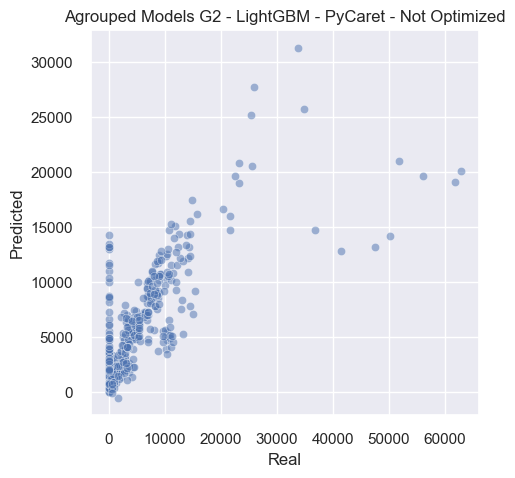

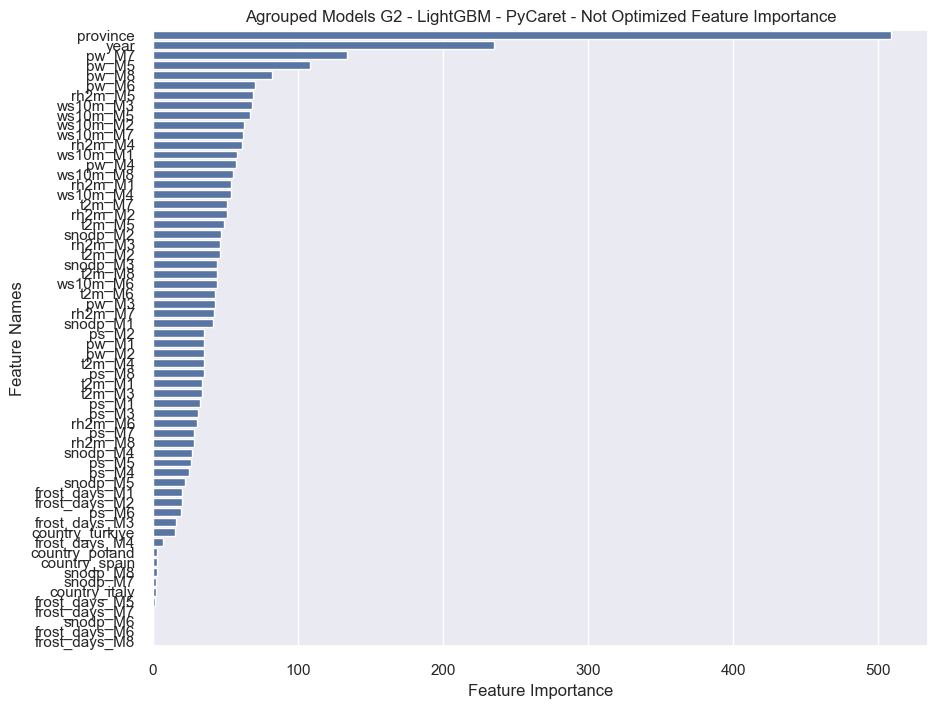

In [146]:
df3 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G2 - LightGBM - PyCaret - Not Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G2 - LightGBM - PyCaret - Not Optimized')
plot_feature_importance(lightgbm_model_g2.feature_importances_, lightgbm_model_g2.feature_names_in_, 'Agrouped Models G2 - LightGBM - PyCaret - Not Optimized')

In [147]:
param_distributions = {
    'n_estimators': randint(50, 1000),           # Número de árboles
    'learning_rate': uniform(0.01, 0.5),       # Tasa de aprendizaje
    'num_leaves': randint(20, 100),             # Número máximo de hojas por árbol
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_child_samples': randint(5, 100),       # Muestras mínimas por nodo hoja
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}

tuned_lgbm_model_g2 = tune_model(lightgbm_model_g2, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,1896.3830,11970551.0667,3459.8484,0.5050,3.9261,2.1724
1,1916.3955,8845224.0680,2974.0921,0.6816,3.7522,0.6213
2,1419.4372,6381779.1135,2526.2183,0.7725,4.0807,2.3378
3,1694.5282,8276483.0117,2876.8877,0.5353,3.4386,1.0286
4,1647.7977,8137018.4146,2852.5460,0.5633,3.5946,0.5525
5,1634.5997,6454150.1773,2540.5020,0.6488,3.9472,1.7249
6,1924.2927,18635707.4850,4316.9095,0.5277,3.4373,0.7122
7,2047.3614,15378833.3452,3921.5856,0.5755,3.8862,0.5538
8,2561.6962,33907280.3858,5822.9958,0.4897,3.5599,0.5140


Fitting 10 folds for each of 100 candidates, totalling 1000 fits


In [148]:
predictions_train_lgbm = predict_model(tuned_lgbm_model_g2, data = train_g2)
predictions_test_lgbm = predict_model(tuned_lgbm_model_g2, data = test_g2)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,677.4405,4351286.5907,2085.9738,0.8556,2.9463,0.5471


[LightGBM] [Warning] Unknown parameter: min_samples_split


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2600.8245,30073362.6262,5483.9185,0.5926,3.2980,2.8833


[LightGBM] [Warning] Unknown parameter: min_samples_split


MAE Train: 677.44
R2 Train: 0.86
MAE Test: 2600.82
R2 Test: 0.59


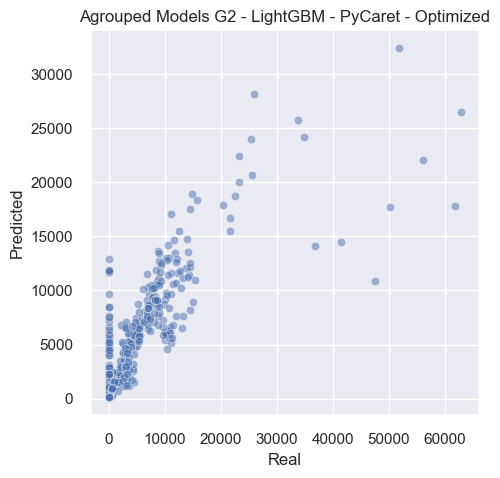

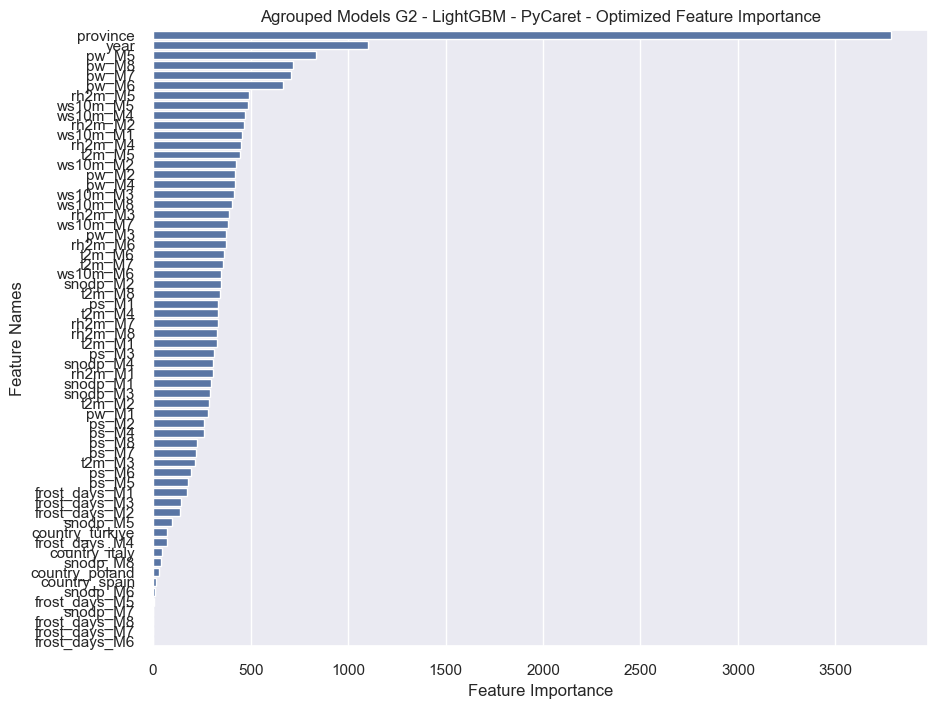

In [149]:
df4 = evaluate_metrics(predictions_train_lgbm['yield'], predictions_train_lgbm['prediction_label'], 
                       predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                       title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
plot_predictions(predictions_test_lgbm['yield'], predictions_test_lgbm['prediction_label'], 
                 title='Agrouped Models G2 - LightGBM - PyCaret - Optimized')
plot_feature_importance(tuned_lgbm_model_g2.feature_importances_, tuned_lgbm_model_g2.feature_names_in_, 'Agrouped Models G2 - LightGBM - PyCaret - Optimized')

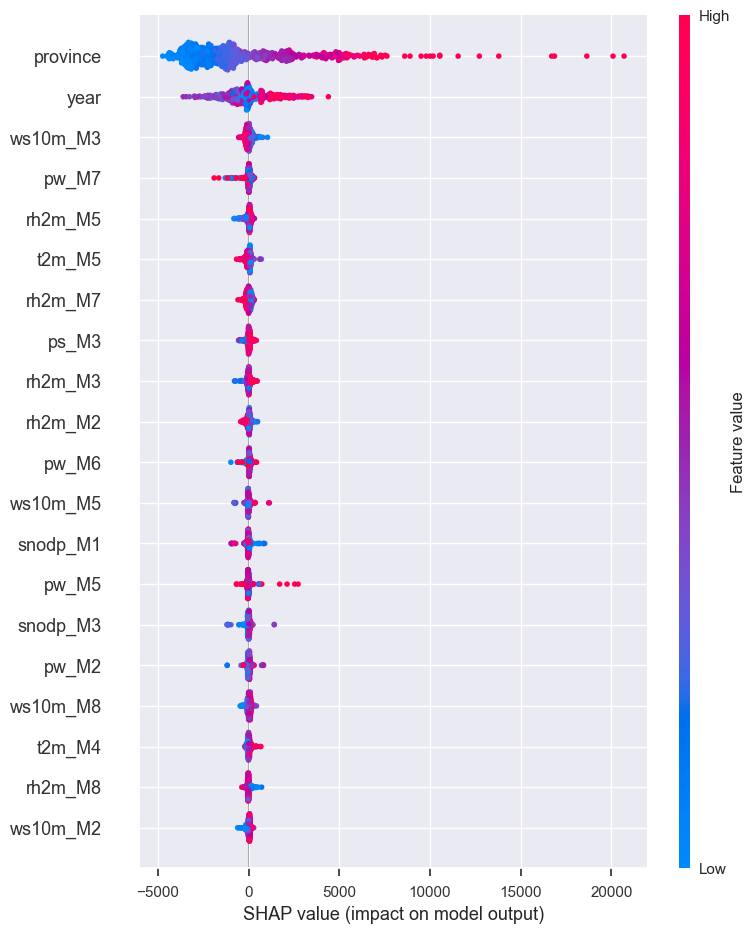

In [150]:
interpret_model(tuned_lgbm_model_g2)

#### Model for Group 3: All countries except France, Italy, Turkey, Poland and Spain

In [203]:
df_group3.head()

,province,country,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8,code
46,agder og rogaland (statistical region 2016),norway,2000,0.0,-0.576129,-1.105517,-0.789355,2.118000,9.329677,9.664000,...,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,NO
47,agder og rogaland (statistical region 2016),norway,2001,0.0,-3.276452,-5.690000,-4.100645,0.360333,7.806129,9.713333,...,0.0,0.527742,0.402143,0.453226,0.656000,0.961290,1.140667,1.526452,1.533226,NO
48,agder og rogaland (statistical region 2016),norway,2002,0.0,-0.516452,-1.166071,-0.950000,2.403667,9.261290,11.837000,...,0.0,0.697419,0.588214,0.540000,0.812333,1.038387,1.249667,1.616452,1.820645,NO
49,agder og rogaland (statistical region 2016),norway,2003,0.0,-3.441290,-3.348214,0.056129,3.698000,6.501935,12.130000,...,0.0,0.600000,0.516429,0.654839,0.687000,0.884839,1.382333,1.738710,1.484516,NO
50,agder og rogaland (statistical region 2016),norway,2004,0.0,-4.133548,-1.846897,-0.667742,3.950000,7.887419,10.128000,...,0.0,0.507419,0.573448,0.597097,0.869667,0.955161,1.202333,1.352903,1.664516,NO


In [204]:
train_g3 = df_group3[df_group3['year'] < min(backtestings_years)].copy()
test_g3  = df_group3[df_group3['year'].isin(backtestings_years)].copy()

In [205]:
from pycaret.regression import *
s = setup(data = train_g3, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['code'],
          categorical_features = ['province','country'])

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(4902, 61)"
4,Transformed data shape,"(4902, 60)"
5,Transformed train set shape,"(3431, 60)"
6,Transformed test set shape,"(1471, 60)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,2


In [206]:
best_model_g3 = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,611.0019,2319894.8206,1512.2082,0.7371,2.8519,0.9686,0.2030
lightgbm,Light Gradient Boosting Machine,677.7180,2396110.8837,1535.4438,0.7283,3.5420,1.2091,0.1790
gbr,Gradient Boosting Regressor,750.7316,2750513.6013,1646.1254,0.6899,3.6966,1.2809,0.4990
rf,Random Forest Regressor,671.6907,2773864.1534,1653.3061,0.6843,2.8432,1.1027,0.6890
knn,K Neighbors Regressor,733.5064,3109475.9750,1755.2160,0.6473,2.5925,0.6056,0.0320
en,Elastic Net,906.2600,3395608.0409,1828.0619,0.6198,4.3024,2.2852,0.0240
br,Bayesian Ridge,892.6226,3396434.6698,1828.0270,0.6197,4.2530,2.0991,0.0210
lasso,Lasso Regression,921.2851,3403989.4175,1830.3213,0.6189,4.3297,2.4382,0.0350
llar,Lasso Least Angle Regression,921.0488,3404289.2114,1830.4080,0.6189,4.3305,2.4420,0.0200
ridge,Ridge Regression,925.4301,3408303.8878,1831.4328,0.6184,4.3396,2.5311,0.0230


In [207]:
et_model_g3 = create_model('et')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,620.6490,2570250.0705,1603.1999,0.7190,2.5802,0.4854
1,642.5158,2823353.6490,1680.2838,0.6124,2.9758,0.9751
2,666.7091,2671184.2205,1634.3758,0.7640,2.8720,0.7084
3,644.3741,3212755.7427,1792.4162,0.6271,2.7784,0.6643
4,564.0710,1505114.1341,1226.8309,0.7801,2.8184,0.4773
5,704.9943,2618274.8984,1618.1084,0.7280,3.0741,0.6780
6,584.3580,1805712.9309,1343.7682,0.7855,2.9648,0.3798
7,574.8731,2474360.9774,1573.0102,0.7516,3.0217,0.4532
8,530.9440,1909560.1518,1381.8684,0.7991,2.6751,0.5172


In [208]:
predictions_train_et = predict_model(et_model_g3, data = train_g3)
predictions_test_et = predict_model(et_model_g3, data = test_g3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,182.6730,702128.1259,837.9309,0.9208,1.5366,0.2018


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,837.7849,3472586.0131,1863.4876,0.6613,3.3164,1.1348


MAE Train: 182.67
R2 Train: 0.92
MAE Test: 837.78
R2 Test: 0.66


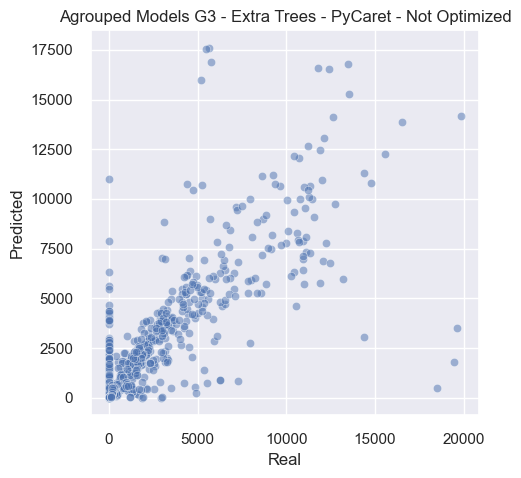

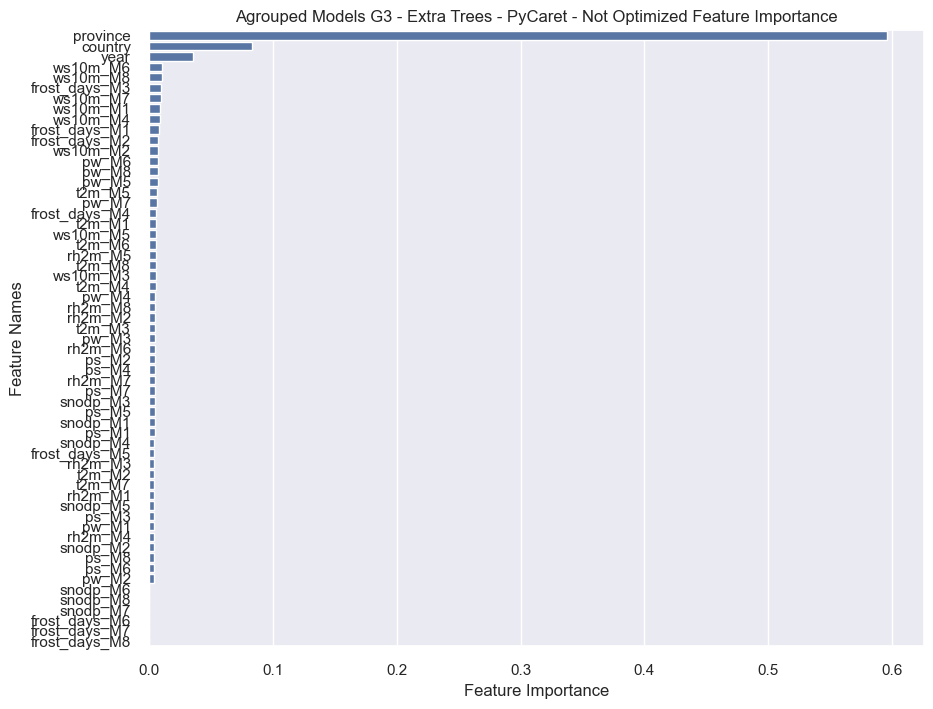

In [209]:
df5 = evaluate_metrics(predictions_train_et['yield'], predictions_train_et['prediction_label'], 
                       predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                       title='Agrouped Models G3 - Extra Trees - PyCaret - Not Optimized')
plot_predictions(predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                 title='Agrouped Models G3 - Extra Trees - PyCaret - Not Optimized')
plot_feature_importance(et_model_g3.feature_importances_, et_model_g3.feature_names_in_, 'Agrouped Models G3 - Extra Trees - PyCaret - Not Optimized')

In [210]:
param_distributions = {
    'n_estimators': randint(5, 1000),           # Número de árboles
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 # Profundidad máxima (-1 = ilimitada)
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}
tuned_et_model_g3 = tune_model(et_model_g3, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,601.0388,2425824.0738,1557.5057,0.7348,2.6246,0.5069
1,632.4748,2627653.8158,1621.0040,0.6393,3.0455,1.1680
2,663.4823,2659153.8402,1630.6912,0.7650,2.9133,0.7680
3,648.0493,3179892.0554,1783.2252,0.6309,2.8537,0.6533
4,589.1016,1709713.3476,1307.5601,0.7502,2.9118,0.4969
5,723.2474,2750779.3011,1658.5473,0.7142,3.1252,0.6432
6,566.6273,1727785.1598,1314.4524,0.7948,2.9652,0.4071
7,594.8235,2605350.1554,1614.1097,0.7385,3.0691,0.4895
8,539.9163,1889216.4452,1374.4877,0.8012,2.6960,0.4775


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [211]:
predictions_train_et = predict_model(tuned_et_model_g3, data = train_g3)
predictions_test_et = predict_model(tuned_et_model_g3, data = test_g3)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,182.6730,702128.1259,837.9309,0.9208,1.5366,0.2018


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Extra Trees Regressor,837.7849,3472586.0131,1863.4876,0.6613,3.3164,1.1348


MAE Train: 182.67
R2 Train: 0.92
MAE Test: 837.78
R2 Test: 0.66


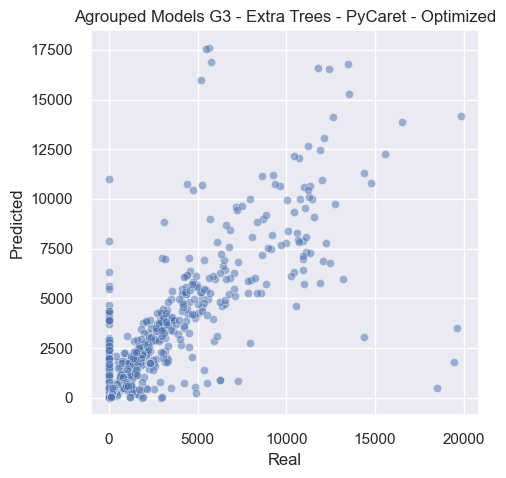

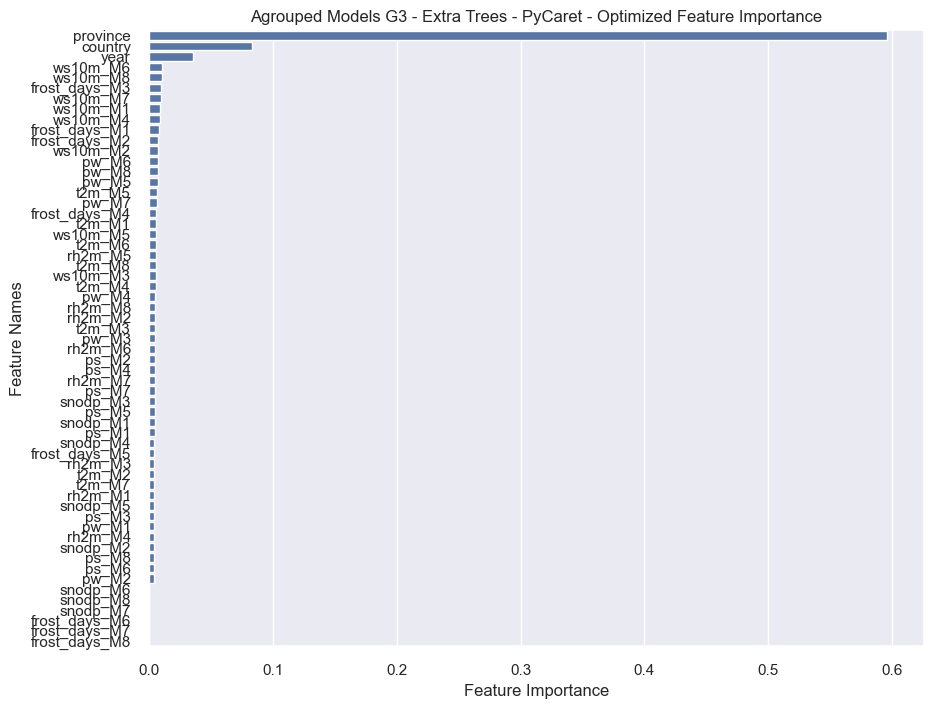

In [212]:
df6 = evaluate_metrics(predictions_train_et['yield'], predictions_train_et['prediction_label'], 
                       predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                       title='Agrouped Models G3 - Extra Trees - PyCaret - Optimized')
plot_predictions(predictions_test_et['yield'], predictions_test_et['prediction_label'], 
                 title='Agrouped Models G3 - Extra Trees - PyCaret - Optimized')
plot_feature_importance(tuned_et_model_g3.feature_importances_, tuned_et_model_g3.feature_names_in_, 'Agrouped Models G3 - Extra Trees - PyCaret - Optimized')

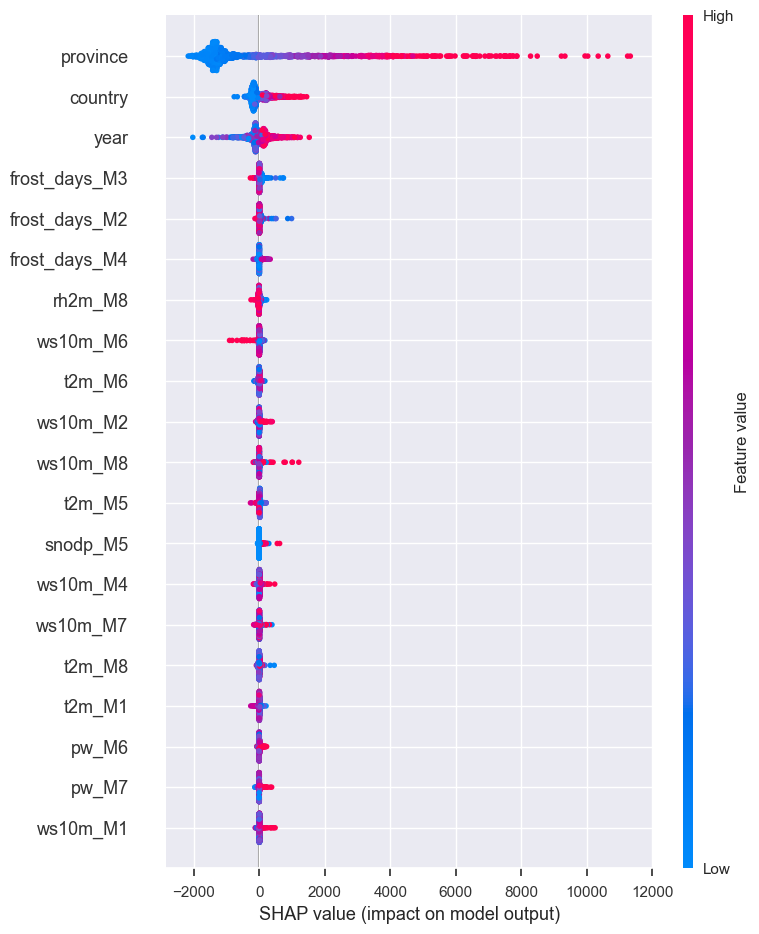

In [213]:
interpret_model(tuned_lgbm_model_g3)

#### CONCLUSION

As can be seen, dividing countries into groups has worked efficiently by reducing the MAE of the predictions by province, making the error of highs not propagate into lows. That is why we will use this approach in the final model of notebook 3.

### Grouped by Country for basic model

#### Info Setup

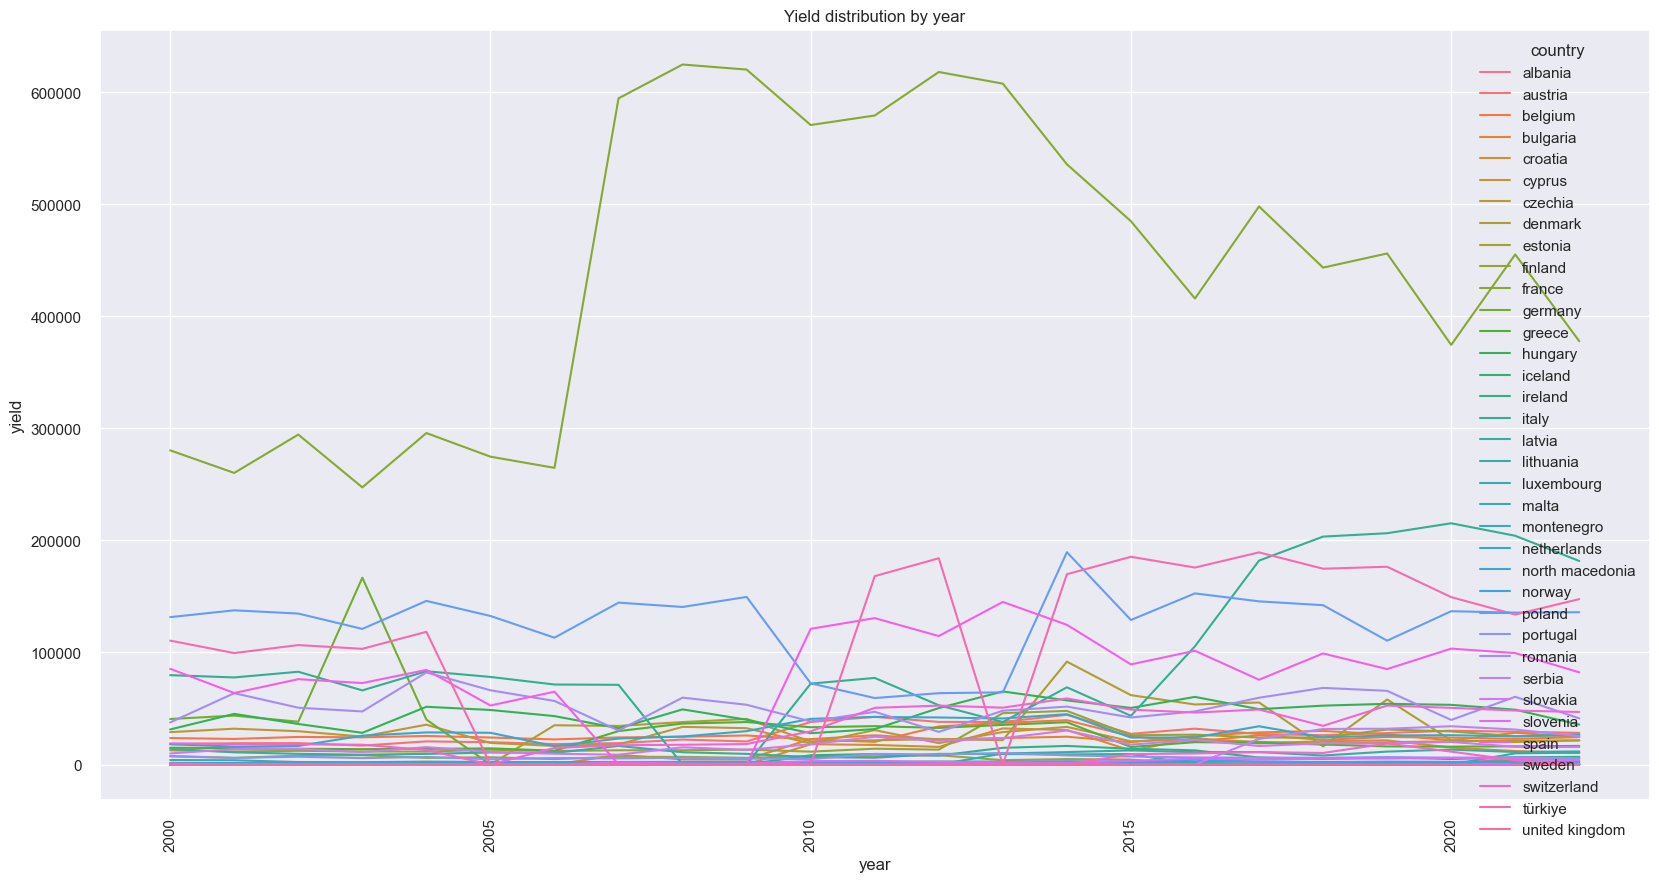

In [214]:
data_grouped = data.groupby(['country','year']).agg({'yield':'sum'}).reset_index()

plt.figure(figsize=(20, 10))
sns.lineplot(data=data_grouped, 
             x='year', y='yield', hue='country')
plt.title('Yield distribution by year')
plt.xticks(rotation=90)
plt.show()

In [215]:
dg1 = data.groupby(['country','code','year']).agg({'yield':'sum'})
dg2 = data.groupby(['country','code','year']).agg({k:'mean' for k in data.columns if k not in ['province','country','code','year', 'yield']})

dfg = pd.concat([dg1, dg2], axis=1).reset_index()

#### Agrouped Yield by Country - Random Forest

In [216]:
dfg.head()

,country,code,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M7,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8
0,albania,AL,2000,0.0,1.052366,4.948506,7.369247,13.878111,18.736667,23.401556,...,0.0,0.0,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995
1,albania,AL,2001,0.0,6.586237,6.108095,11.488065,11.158667,17.951505,21.090778,...,0.0,0.0,1.044624,0.737262,1.140000,1.122333,1.656667,1.556667,1.939462,2.089785
2,albania,AL,2002,0.0,3.491613,8.464762,10.109677,12.466667,17.955054,23.491111,...,0.0,0.0,0.744731,0.846667,1.000215,1.166000,1.618817,1.843111,2.241935,2.224946
3,albania,AL,2003,0.0,6.003333,1.072024,6.766022,10.777556,20.730645,25.869556,...,0.0,0.0,0.945484,0.472262,0.657957,0.995444,1.520860,2.084667,1.799355,1.991290
4,albania,AL,2004,0.0,3.008495,5.377931,8.385591,12.973333,14.845376,20.925000,...,0.0,0.0,0.733226,0.784828,0.899677,1.292778,1.278602,1.900778,1.884409,1.859355


In [217]:
train_n = dfg[dfg['year'] < min(backtestings_years)].copy()
test_n  = dfg[dfg['year'].isin(backtestings_years)].copy()

In [218]:
from pycaret.regression import *
s = setup(data = train_n, target = 'yield', 
          session_id=random_state, 
          ignore_features = ['code'],
          categorical_features = ['country'])

,Description,Value
0,Session id,21
1,Target,yield
2,Target type,Regression
3,Original data shape,"(684, 60)"
4,Transformed data shape,"(684, 59)"
5,Transformed train set shape,"(478, 59)"
6,Transformed test set shape,"(206, 59)"
7,Ignore features,1
8,Numeric features,57
9,Categorical features,1


In [219]:
best_model_n = compare_models()

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,07:34:16
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,14500.5227,1175978709.1078,31849.7339,0.7981,4.1711,1.6958,0.1030
par,Passive Aggressive Regressor,17797.8189,1252372340.2713,33766.9300,0.7968,4.9708,10.7515,0.0170
huber,Huber Regressor,16288.8428,1307058478.7337,33682.7374,0.7967,4.7389,5.6223,0.0150
br,Bayesian Ridge,17119.4430,1351984400.7630,34526.2582,0.7928,4.9405,9.8502,0.0140
gbr,Gradient Boosting Regressor,14575.9404,1012259488.0549,29520.3273,0.7878,4.6765,7.1899,0.0900
omp,Orthogonal Matching Pursuit,17096.4970,1307934240.0695,34109.6243,0.7873,4.9581,9.7046,0.0130
en,Elastic Net,17736.6218,1346591077.6890,34596.1600,0.7823,4.9718,10.4069,0.0150
et,Extra Trees Regressor,13555.1539,1096938725.1401,31440.9912,0.7765,4.1224,1.1041,0.0540
ridge,Ridge Regression,19542.4366,1410981638.0241,35652.5549,0.7609,5.1559,18.3940,0.0130
llar,Lasso Least Angle Regression,20182.5749,1433630922.3865,36038.9816,0.7530,5.1934,21.1055,0.0160


In [220]:
rf_model_g = create_model('rf')

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,13892.5787,927404177.6110,30453.3114,0.9351,3.7465,2.2483
1,16635.9567,1441582350.4560,37968.1755,0.2932,4.0092,4.7200
2,24315.3898,3848865702.6793,62039.2271,0.7637,4.4194,0.5965
3,7838.9606,204096445.6485,14286.2327,0.6803,4.3010,0.6189
4,12659.2543,807568717.4295,28417.7536,0.9026,3.7513,1.7377
5,10923.6140,390673098.5416,19765.4521,0.9480,3.7637,2.8849
6,18725.1266,1520879339.8601,38998.4530,0.8541,4.2248,0.7092
7,9990.3755,398475811.3200,19961.8589,0.9319,4.2696,0.6543
8,14405.5553,1176787410.6778,34304.3352,0.7514,4.8685,1.1888


In [221]:
predictions_train_rf = predict_model(rf_model_g, data = train_n)
predictions_test_rf = predict_model(rf_model_g, data = test_n)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,6402.0620,210686808.8216,14515.0546,0.9687,3.6254,0.8002


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,12142.6356,638163744.8248,25261.9030,0.8958,3.4598,1.6368


MAE Train: 6402.06
R2 Train: 0.97
MAE Test: 12142.64
R2 Test: 0.90


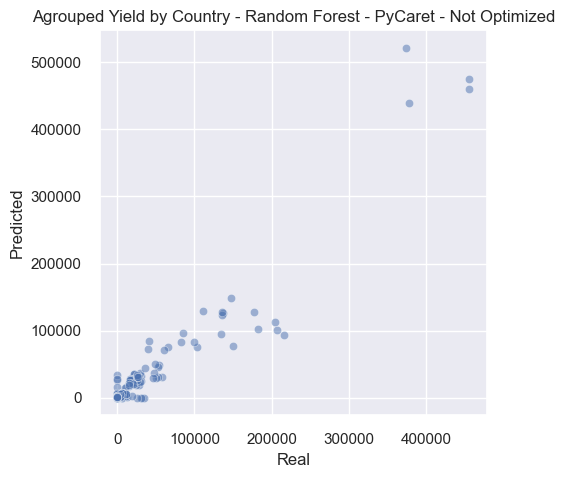

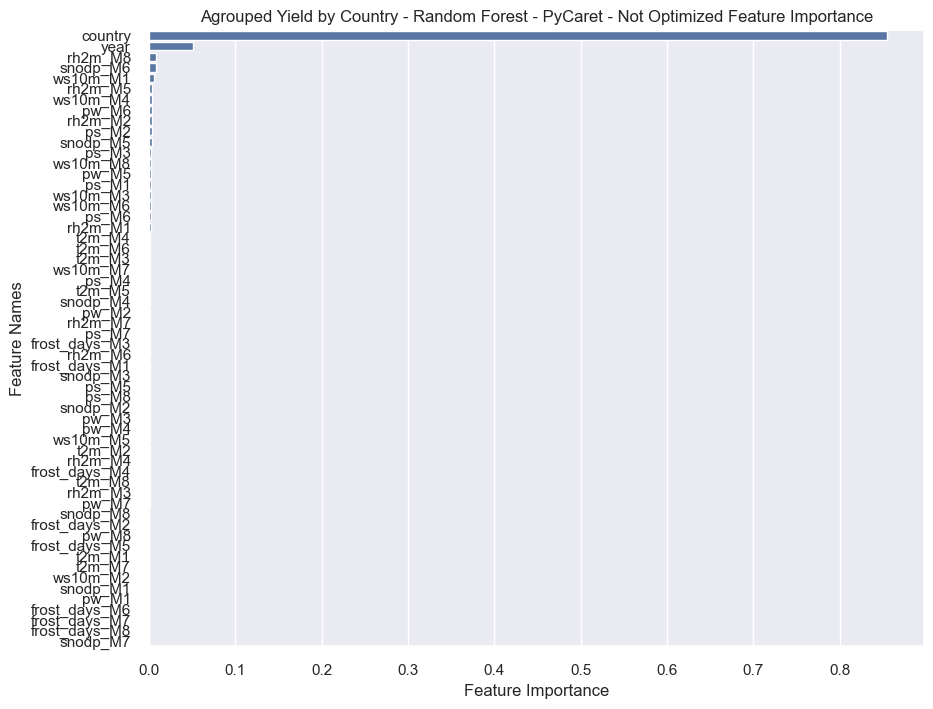

In [222]:
df7 = evaluate_metrics(predictions_train_rf['yield'], predictions_train_rf['prediction_label'], 
                       predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                       title='Agrouped Yield by Country - Random Forest - PyCaret - Not Optimized')
plot_predictions(predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                 title='Agrouped Yield by Country - Random Forest - PyCaret - Not Optimized')
plot_feature_importance(rf_model_g.feature_importances_, rf_model_g.feature_names_in_, 'Agrouped Yield by Country - Random Forest - PyCaret - Not Optimized')

In [225]:
param_distributions = {
    'n_estimators': randint(5, 1000),           # Número de árboles
    'max_depth': [-1, 10, 20, 30, 40, 50, 100, 150],                 
    'min_samples_split': randint(5, 100),       # Muestras mínimas para dividir un nodo
}
tuned_rf_model_n = tune_model(rf_model_g, n_iter = 100, optimize = 'MAE', choose_better = True, custom_grid=param_distributions )

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,07:42:02
Status,. . . . . . . . . . . . . . . . . .,Loading Dependencies
Estimator,. . . . . . . . . . . . . . . . . .,Compiling Library


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,13748.0169,893417820.1768,29890.0957,0.9375,3.7494,1.9613
1,17025.3048,1486551119.3644,38555.8182,0.2711,4.0919,4.6259
2,23988.6326,3822732654.7638,61828.2513,0.7653,4.4282,0.5755
3,7771.8121,209050088.5683,14458.5645,0.6726,4.2955,0.6082
4,12458.0606,825227120.1539,28726.7666,0.9005,3.7475,1.6598
5,11124.7768,435666369.3203,20872.6225,0.9420,3.7842,3.6201
6,19019.3403,1634325592.1710,40426.7930,0.8432,4.2586,0.6158
7,9926.2189,432373560.0800,20793.5942,0.9261,4.2883,0.6311
8,14381.0597,1219420819.8061,34920.2065,0.7423,4.8258,1.5181


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


In [226]:
predictions_train_rf = predict_model(tuned_rf_model_n, data = train_n)
predictions_test_rf = predict_model(tuned_rf_model_n, data = test_n)

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,6402.0620,210686808.8216,14515.0546,0.9687,3.6254,0.8002


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,12142.6356,638163744.8248,25261.9030,0.8958,3.4598,1.6368


MAE Train: 6402.06
R2 Train: 0.97
MAE Test: 12142.64
R2 Test: 0.90


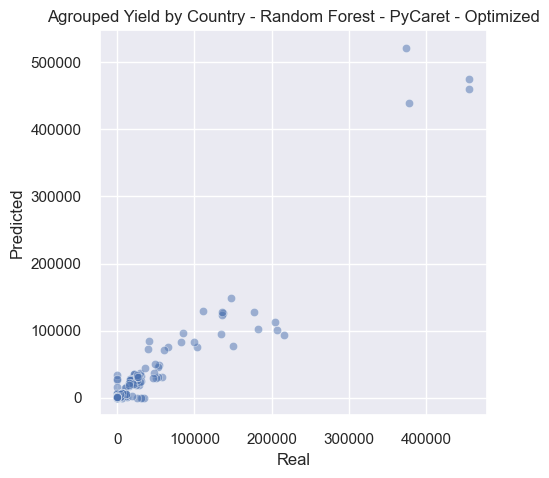

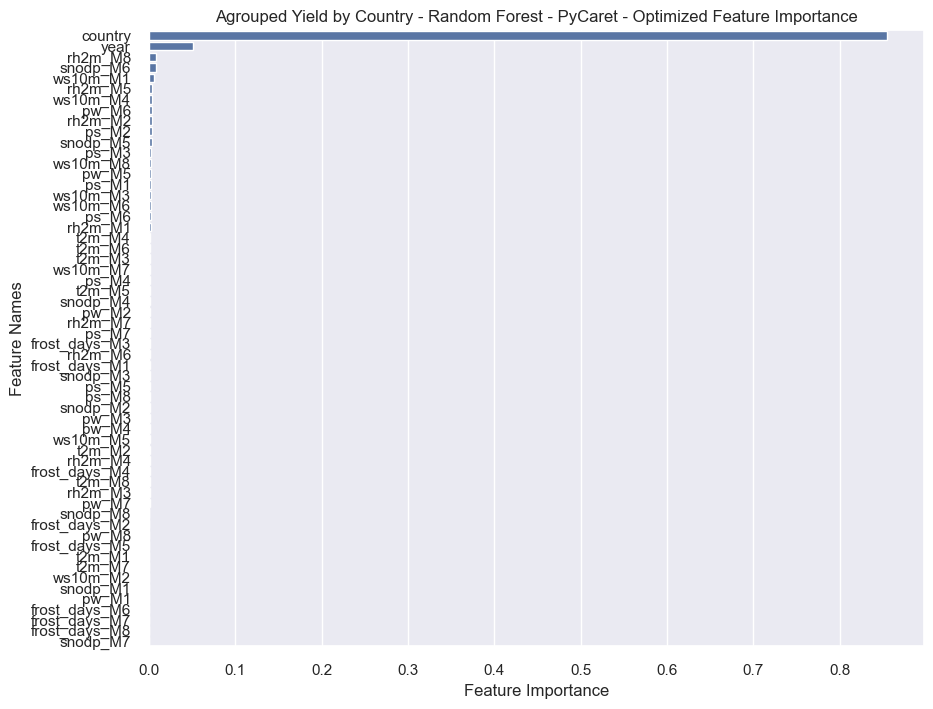

In [227]:
df8 = evaluate_metrics(predictions_train_rf['yield'], predictions_train_rf['prediction_label'], 
                       predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                       title='Agrouped Yield by Country - Random Forest - PyCaret - Optimized')
plot_predictions(predictions_test_rf['yield'], predictions_test_rf['prediction_label'], 
                 title='Agrouped Yield by Country - Random Forest - PyCaret - Optimized')
plot_feature_importance(tuned_rf_model_n.feature_importances_, tuned_rf_model_n.feature_names_in_, 'Agrouped Yield by Country - Random Forest - PyCaret - Optimized')

The Random Forest model was used for practicality and because it has good usage metrics. By using the grouping by country and not subdividing it by province, we see that the data is considerably reduced, making the model have a MAE of 12k yield, and as can be seen this depends a lot on the country, so it would be better to use the country as a dividing medium, since there may be outliers (France) within them and their error can greatly affect those with less Yield.

### Time Series Models

#### Using Propeth

In [228]:
dg1 = data.groupby(['country','code','year']).agg({'yield':'sum'})
dg2 = data.groupby(['country','code','year']).agg({k:'mean' for k in data.columns if k not in ['province','country','code','year', 'yield']})

dfg = pd.concat([dg1, dg2], axis=1).reset_index()

In [233]:
dfg_1 = dfg[dfg['country'].isin(['france'])].copy()
dfg_1.head()

,country,code,year,yield,t2m_M1,t2m_M2,t2m_M3,t2m_M4,t2m_M5,t2m_M6,...,snodp_M7,snodp_M8,pw_M1,pw_M2,pw_M3,pw_M4,pw_M5,pw_M6,pw_M7,pw_M8
230,france,FR,2000,280466.589625,4.651177,7.520387,8.278930,10.947544,15.696129,18.072585,...,0.063667,0.041551,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995,1.821995
231,france,FR,2001,260282.350482,6.150628,6.386266,9.894448,9.847281,15.403226,17.086503,...,0.032722,0.000000,1.585105,1.436416,1.870266,1.668123,2.192592,2.166889,2.658647,2.658297
232,france,FR,2002,294528.798621,6.029796,8.060840,9.602869,11.456316,14.199360,18.841509,...,0.000883,0.038902,1.490153,1.638766,1.635625,1.727099,2.063956,2.539737,2.615529,2.746842
233,france,FR,2003,247426.470069,4.247057,4.255558,9.749553,11.721813,15.356384,21.549877,...,0.000000,0.000000,1.382920,1.301936,1.478404,1.753392,2.166576,2.832368,2.594952,2.824126
234,france,FR,2004,295890.379987,5.804641,5.913539,7.451205,10.949474,13.995388,18.375865,...,0.002649,0.000000,1.576010,1.343436,1.483254,1.741433,1.924103,2.362795,2.579547,2.813265


<Axes: xlabel='year'>

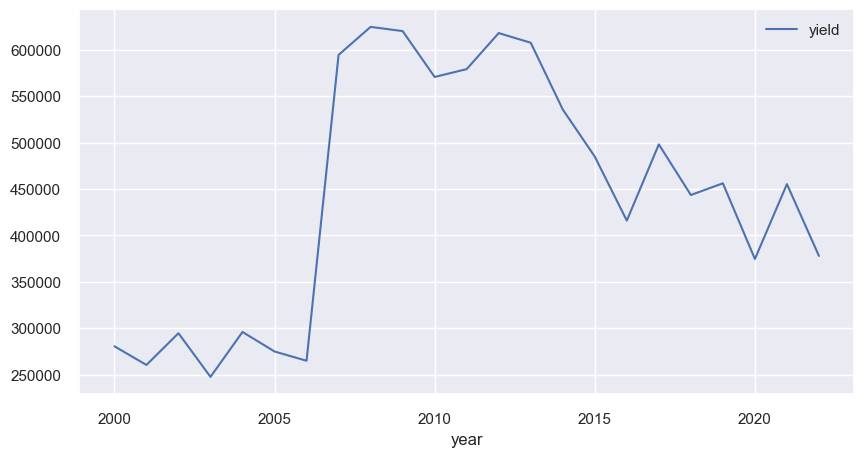

In [234]:
dfg_1[['year','yield']+[k for k in dfg_1.columns if 'M1' in k]].plot(kind='line', x='year', y='yield', figsize=(10, 5))

08:24:05 - cmdstanpy - INFO - Chain [1] start processing
08:24:05 - cmdstanpy - INFO - Chain [1] done processing


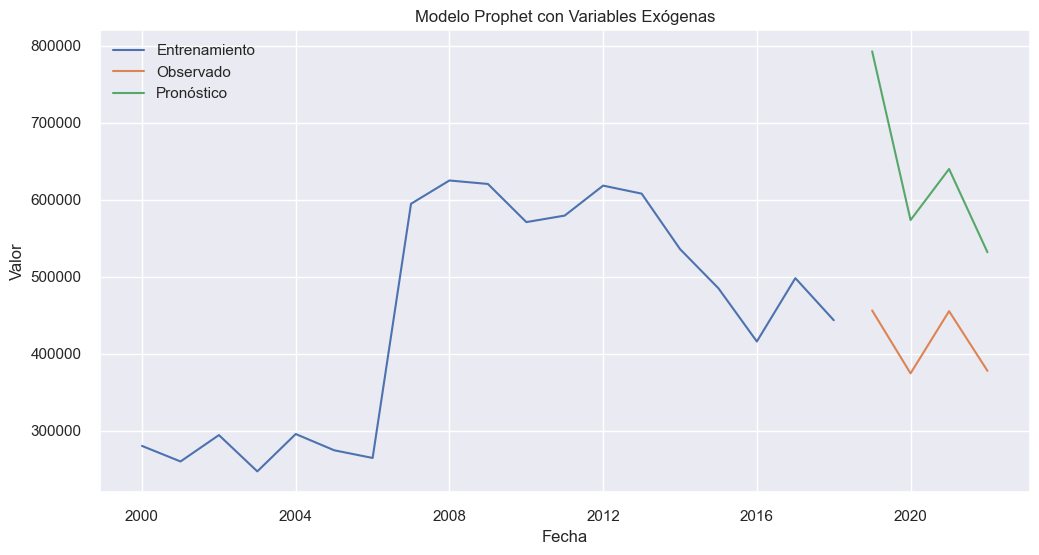

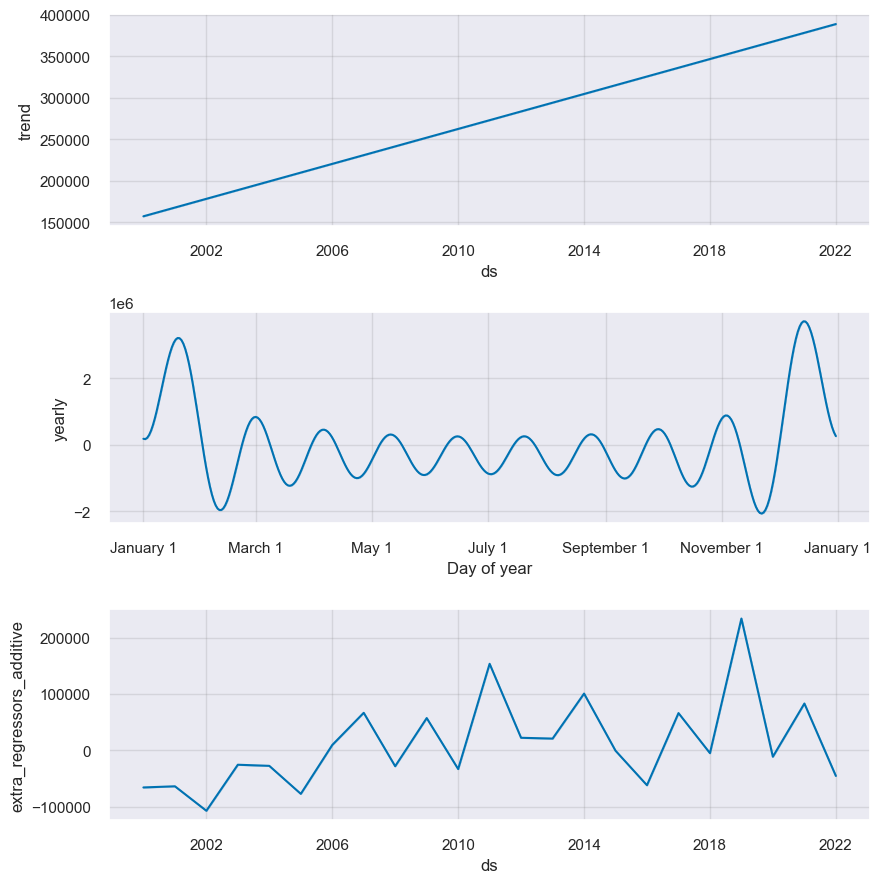

In [ ]:
from prophet import Prophet

dfg_1['ds'] = dfg_1['year'].astype(str)
dfg_1['y'] = dfg_1['yield']

dfg_1['ds'] = pd.to_datetime(dfg_1['year'].astype(str) + '-01-01')

train_t1 = dfg_1[dfg_1['year'] < min(backtestings_years)].copy()
test_t1  = dfg_1[dfg_1['year'].isin(backtestings_years)].copy()

model = Prophet()

exogenous_vars = [k for k in train_t1.columns if 'M2' in k]

for var in exogenous_vars:
    model.add_regressor(var)
    
model.fit(train_t1)
future = model.make_future_dataframe(periods=len(backtestings_years), freq='YS')
future = future.merge(dfg_1[["ds"] + exogenous_vars], on='ds', how='left')
forecast = model.predict(future)

forecast_test = forecast[-len(backtestings_years):]

plt.figure(figsize=(12, 6))
plt.plot(train_t1['ds'], train_t1['y'], label='Entrenamiento')
plt.plot(test_t1['ds'], test_t1['y'], label='Observado')
plt.plot(forecast_test['ds'], forecast_test['yhat'], label='Pronóstico')
plt.legend()
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Modelo Prophet con Variables Exógenas')
plt.show()

model.plot_components(forecast)
plt.show()

In [257]:
future

,ds,t2m_M1,rh2m_M1,ws10m_M1,ps_M1,frost_days_M1,snodp_M1,pw_M1
0,2000-01-01,4.651177,90.297193,4.134182,98.455931,15.368421,9.904793,1.821995
1,2001-01-01,6.150628,90.561890,4.853871,97.302513,10.631579,8.076367,1.585105
2,2002-01-01,6.029796,87.367912,4.406706,98.370453,11.807018,6.448727,1.490153
3,2003-01-01,4.247057,89.160232,5.066508,97.735320,15.842105,8.656304,1.382920
4,2004-01-01,5.804641,89.486921,5.083577,97.375829,12.701754,9.143684,1.576010
5,2005-01-01,5.725869,88.055348,4.796746,98.333480,11.947368,6.859655,1.468393
6,2006-01-01,4.132654,89.614080,4.042716,98.132586,17.701754,10.489015,1.406627
7,2007-01-01,7.646735,90.224052,5.009049,98.196027,7.491228,4.175744,1.668297
8,2008-01-01,7.066978,88.088036,4.740362,97.937929,9.894737,4.885676,1.558687
9,2009-01-01,3.463860,89.466038,4.272168,97.376327,18.491228,12.178947,1.327600


The Propeth model was used, with self-regulating parameters, as a start to the use of time series models, to see their rapid potential. However, in the Yield World, the results are far from reality, so this model will not be used.

#### Using SARIMAX

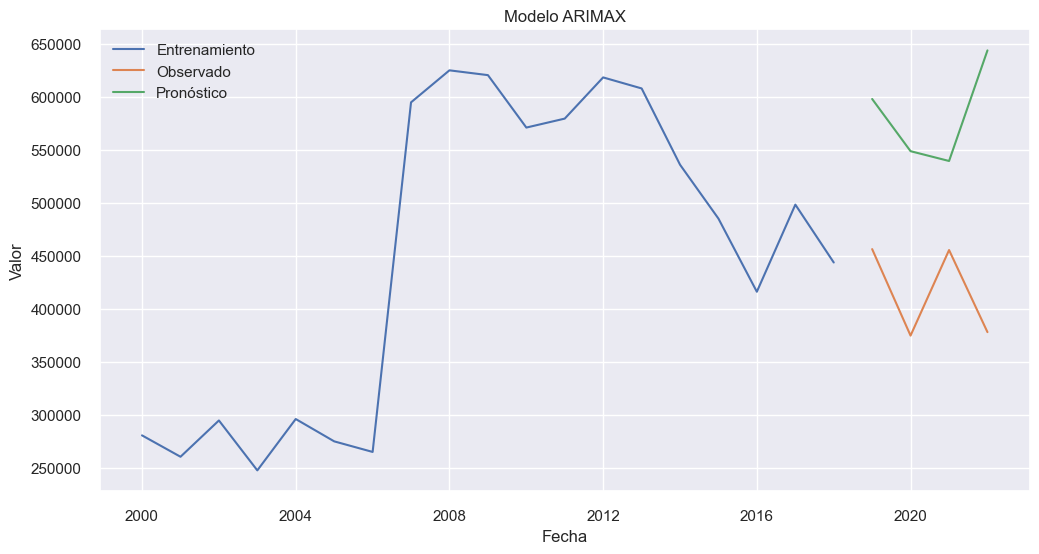

                               SARIMAX Results                                
Dep. Variable:                  yield   No. Observations:                   19
Model:               SARIMAX(1, 0, 1)   Log Likelihood                -246.321
Date:                Mon, 02 Dec 2024   AIC                            512.642
Time:                        08:10:03   BIC                            522.086
Sample:                    01-01-2000   HQIC                           514.240
                         - 01-01-2018                                         
Covariance Type:                  opg                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
t2m_M1         1.508e+05   2.26e+05      0.666      0.505   -2.93e+05    5.94e+05
rh2m_M1        5.915e+04   4.63e+04      1.278      0.201   -3.15e+04     1.5e+05
ws10m_M1      -2.546e+05   2.54e+05     

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_t1 = dfg_1[dfg_1['year'] < min(backtestings_years)].copy()
test_t1  = dfg_1[dfg_1['year'].isin(backtestings_years)].copy()

train_t1.set_index('year', inplace=True)
test_t1.set_index('year', inplace=True)

train_t1.index = pd.to_datetime(train_t1.index, format='%Y')
test_t1.index = pd.to_datetime(test_t1.index, format='%Y')

# Define the exogenous variables for training and testing
exog_train = train_t1[[k for k in train_t1.columns if 'M1' in k]]
exog_test = test_t1[[k for k in test_t1.columns if 'M1' in k]]

# Fit the ARIMAX model
# Adjust the order (p, d, q) based on your series analysis
model = SARIMAX(train_t1['yield'], exog=exog_train, order=(1, 0, 1))
result = model.fit(disp=False)

forecast = result.predict(start=test_t1.index[0], end=test_t1.index[-1], exog=exog_test)

plt.figure(figsize=(12, 6))
plt.plot(train_t1['yield'], label='Entrenamiento')
plt.plot(test_t1['yield'], label='Observado')
plt.plot(forecast, label='Pronóstico')
plt.legend()
plt.xlabel('Fecha')
plt.ylabel('Valor')
plt.title('Modelo ARIMAX')
plt.show()

print(result.summary())

The result of using this model is unsatisfactory, even when basic orders have been placed on only one country. This is why these parameters should be regulated for each country that will not use this type of model.

#### Using Basic Holt-Winters

In [296]:
dg1 = data.groupby(['country','code','year']).agg({'yield':'sum'})
dg2 = data.groupby(['country','code','year']).agg({k:'mean' for k in data.columns if k not in ['province','country','code','year', 'yield']})

dfg = pd.concat([dg1, dg2], axis=1).reset_index()

In [298]:
dfg1 = dfg[dfg['country'].isin(['italy'])].copy()

In [330]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error

def test_holt_winters(data, country, m = 5):
    dfg1 = data[data['country'].isin([country])].copy()
    
    train_t1 = dfg1[dfg1['year'] < min(backtestings_years)].copy()
    test_t1  = dfg1[dfg1['year'].isin(backtestings_years)].copy()

    train_t1.set_index('year', inplace=True)
    test_t1.set_index('year', inplace=True)

    train_t1.index = pd.to_datetime(train_t1.index, format='%Y')
    test_t1.index = pd.to_datetime(test_t1.index, format='%Y')

    # Holt-Winters Exponential Smoothing
    ETS = ExponentialSmoothing(train_t1['yield'].tolist(), seasonal='add', 
                            seasonal_periods=m).fit()
    ETS_pred = ETS.forecast(len(backtestings_years))

    train_pred = pd.DataFrame(ETS.predict(start=0, end=18), columns=['yield'], index=train_t1.index)
    y_pred = pd.DataFrame(ETS_pred, columns=['yield'], index=test_t1.index)
    
    mae_train = mean_absolute_error(train_t1['yield'], train_pred['yield'])
    mae_test  = mean_absolute_error(test_t1['yield'], y_pred['yield'])
    print('MAE Train:', mae_train)
    print('MAE Test', mae_test)
    
    # Data Visualization
    plt.figure(figsize=(12, 6))
    plt.plot(train_t1['yield'], label='Trainig')
    plt.plot(test_t1['yield'], label='Test')
    plt.plot(y_pred, label='Forescast')
    plt.plot(train_pred, label='Train Forescast')
    plt.legend()
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title(f'Holt-Winters Exponential Smoothing - {country} - MAE Train: {mae_train:.2f} - MAE Test: {mae_test:.2f}')
    plt.show()

    return mae_train, mae_test

MAE Train: 64866.45560115371
MAE Test 67318.37480442906


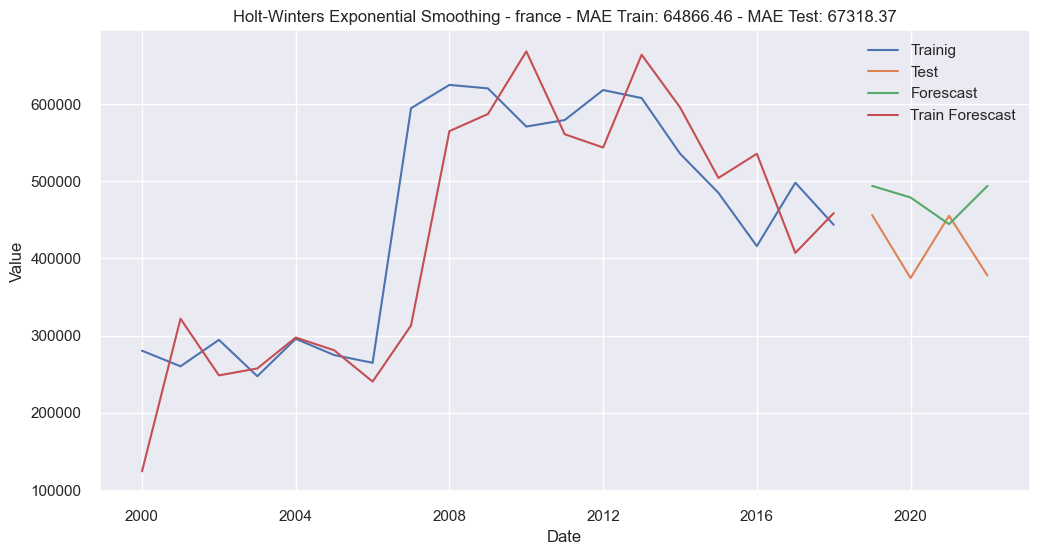

MAE Train: 58797.418963440716
MAE Test 78302.15567813428


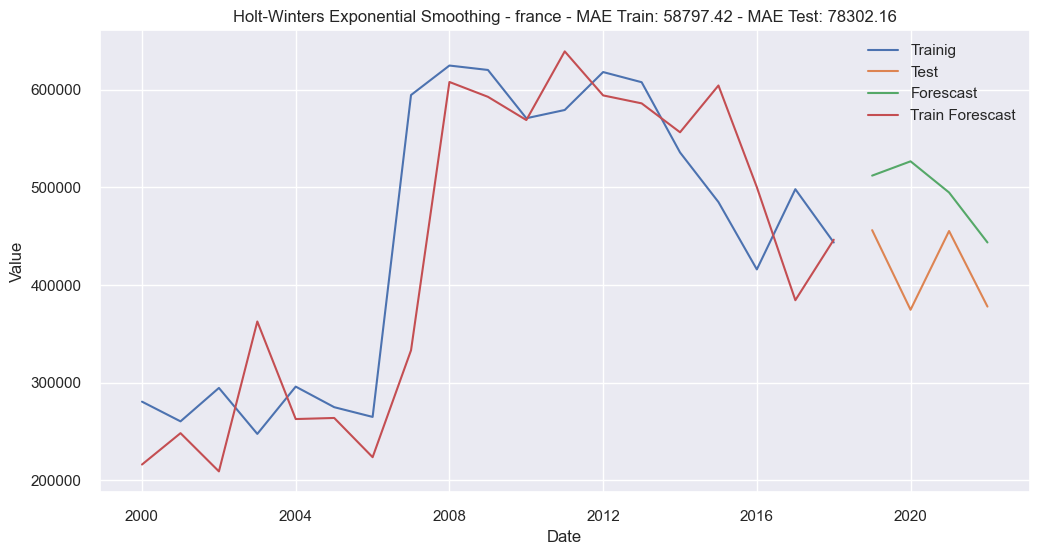

MAE Train: 54868.444085407464
MAE Test 62295.65098095924


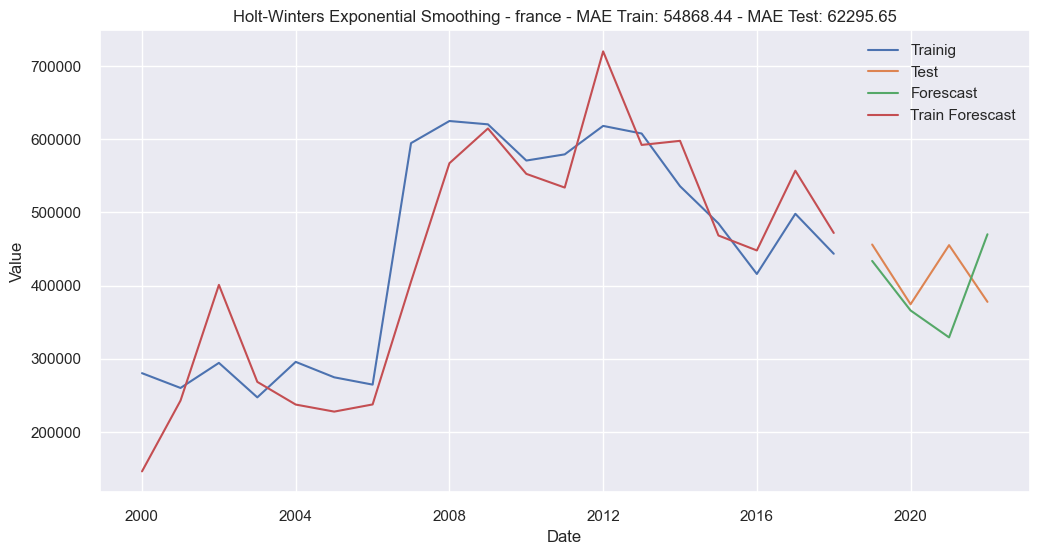

MAE Train: 24940.637757680048
MAE Test 14338.439527301445


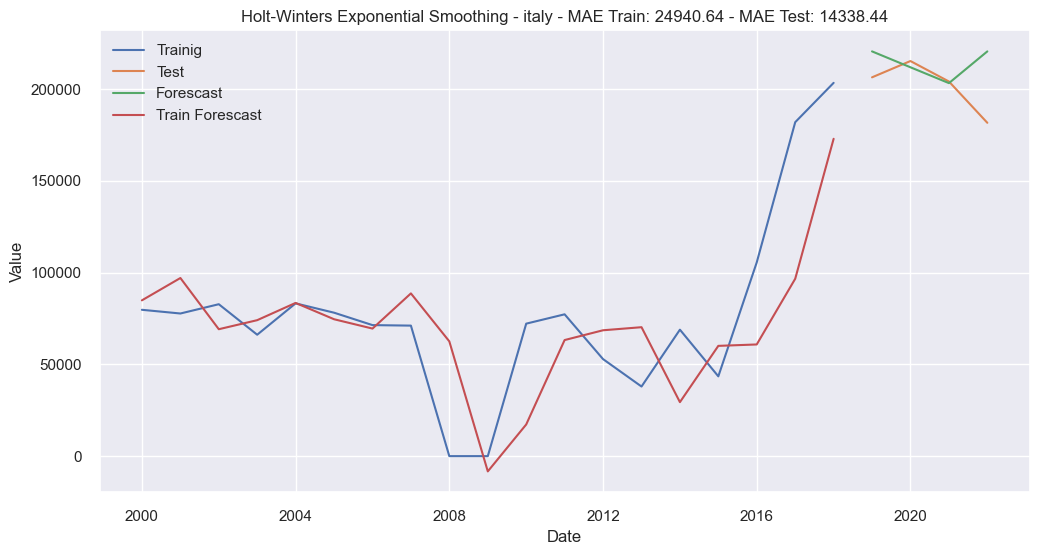

MAE Train: 23223.391042351574
MAE Test 23442.344007245665


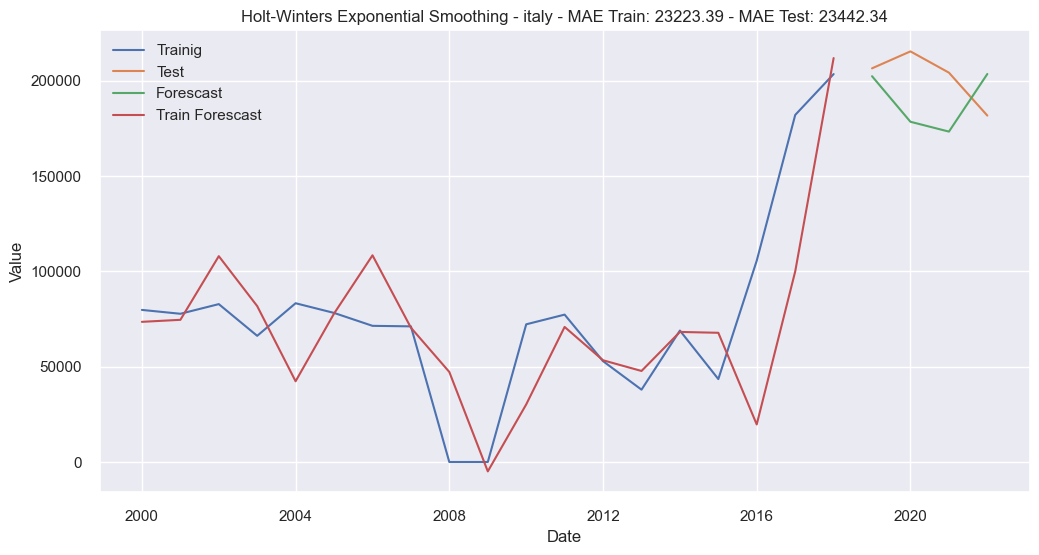

MAE Train: 28429.786516613436
MAE Test 35273.10473919541


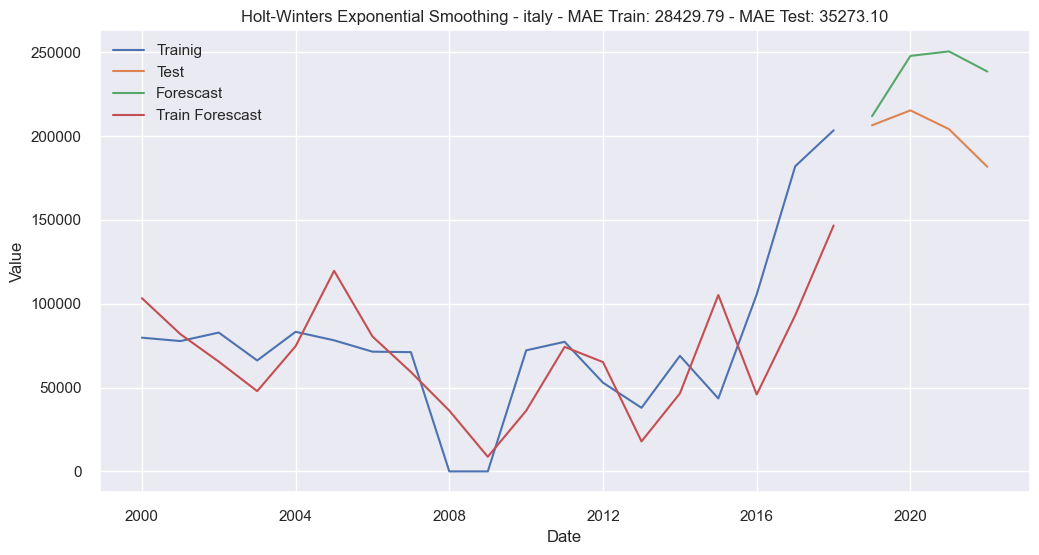

MAE Train: 50678.809649136754
MAE Test 28479.787680500747


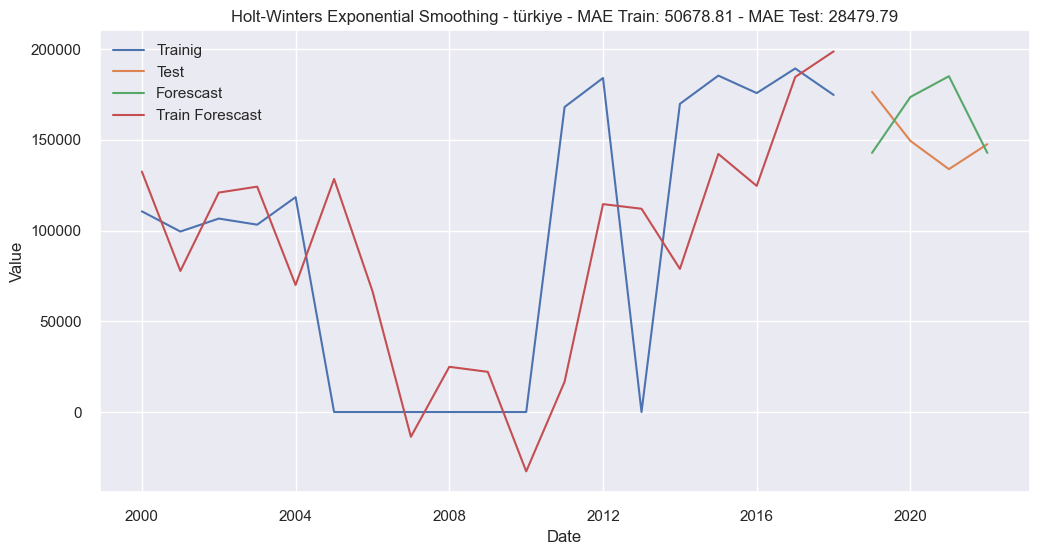

MAE Train: 48950.749950730045
MAE Test 47409.94204623269


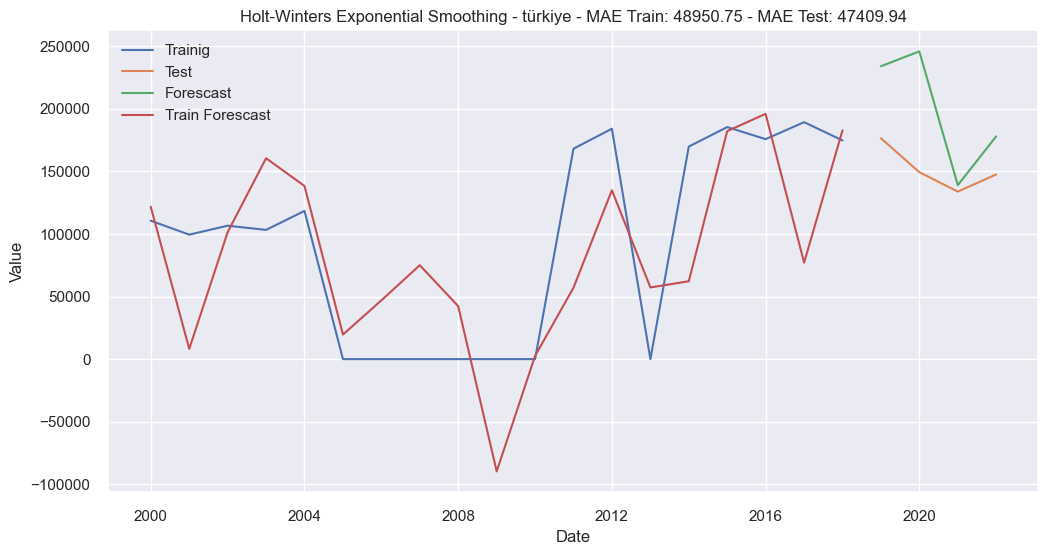

MAE Train: 56745.19519871221
MAE Test 36105.27071499816


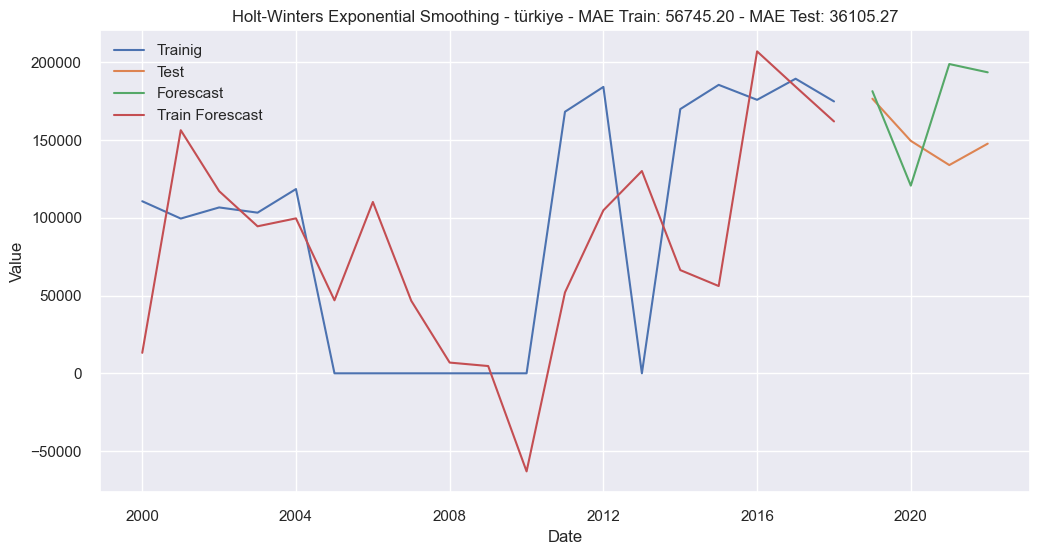

MAE Train: 22900.74665494462
MAE Test 10550.195940245649


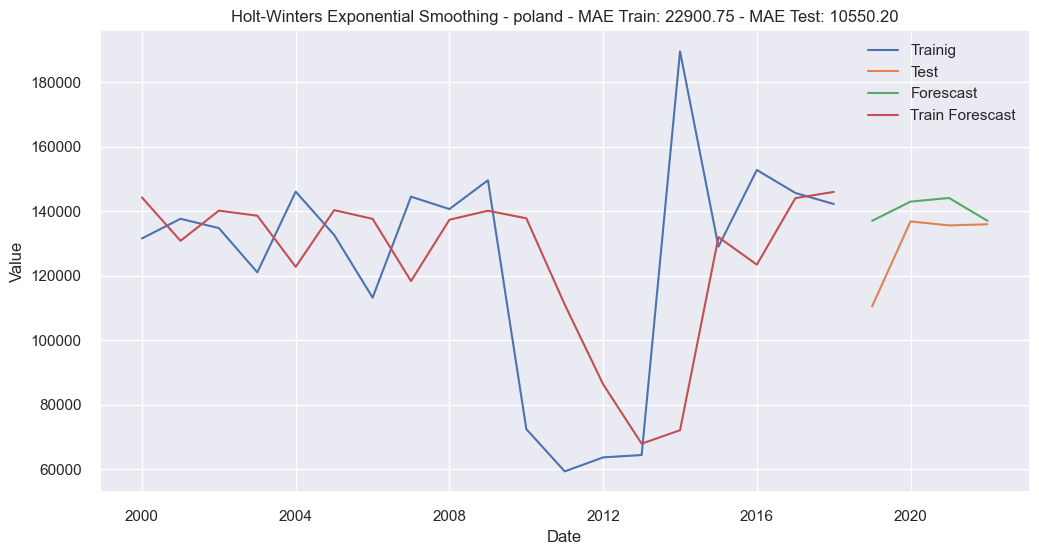

MAE Train: 22960.390354109102
MAE Test 15136.602320553553


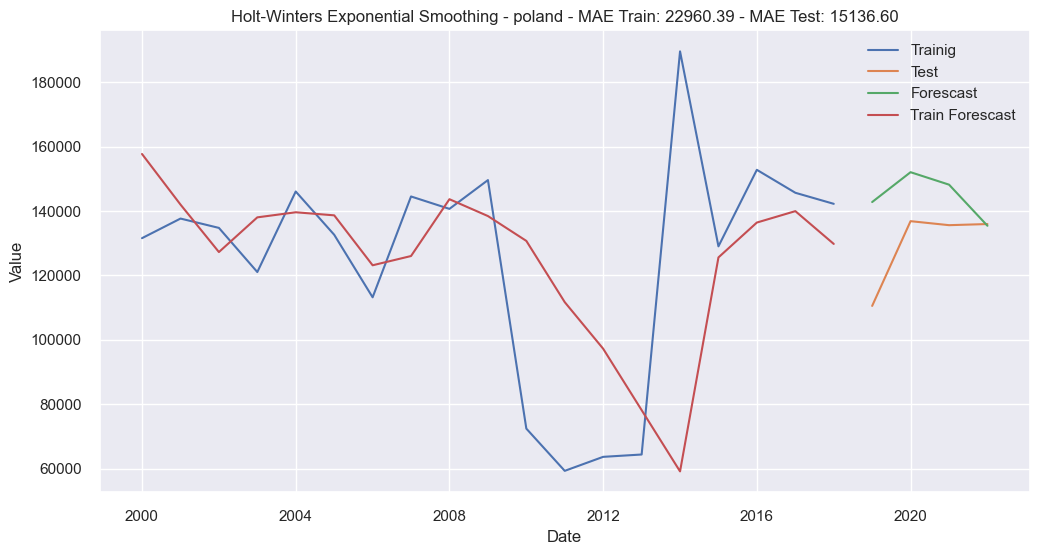

MAE Train: 20002.587796783246
MAE Test 20741.201679090795


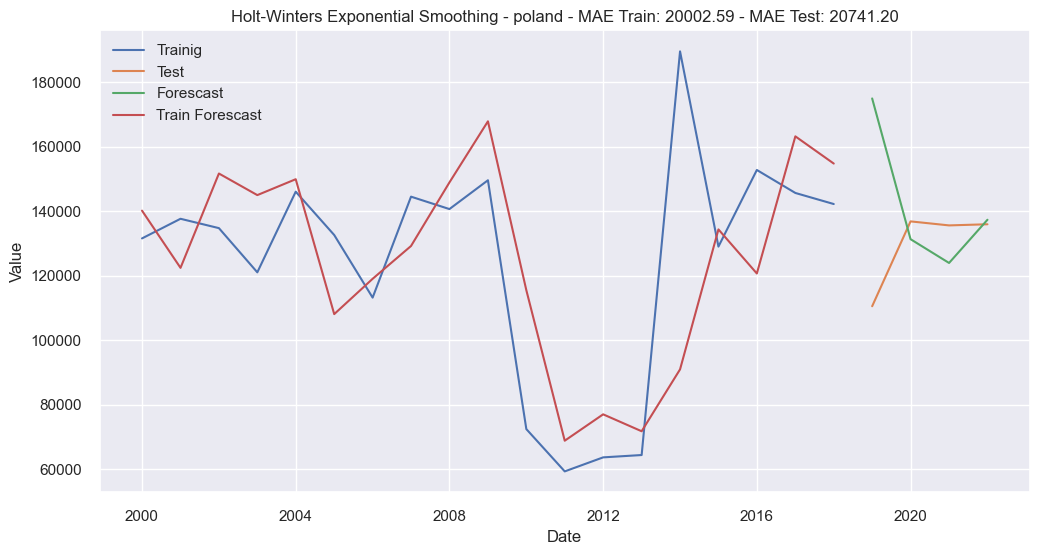

MAE Train: 24091.805579149095
MAE Test 15644.729088861917


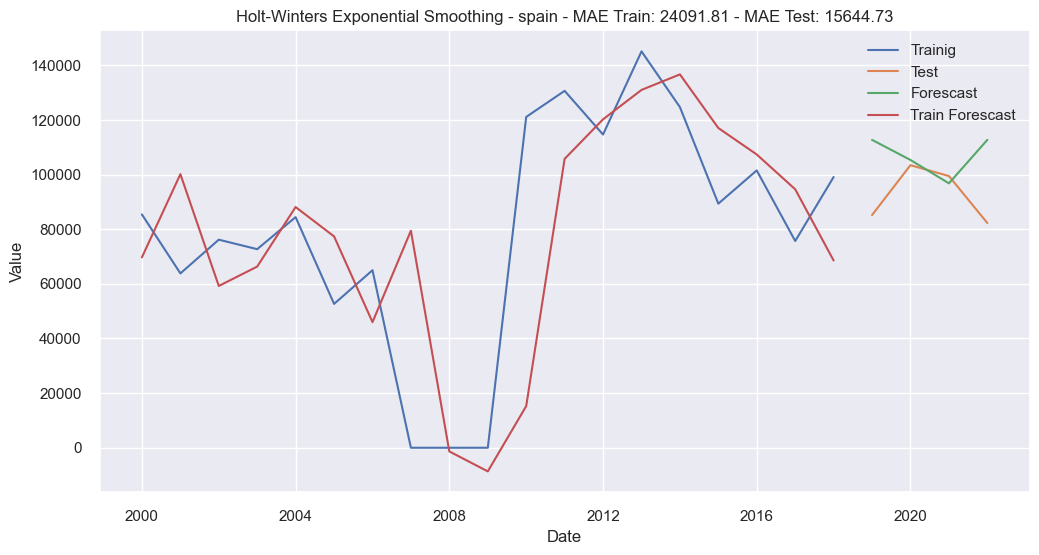

MAE Train: 26355.93825712364
MAE Test 24255.472017979348


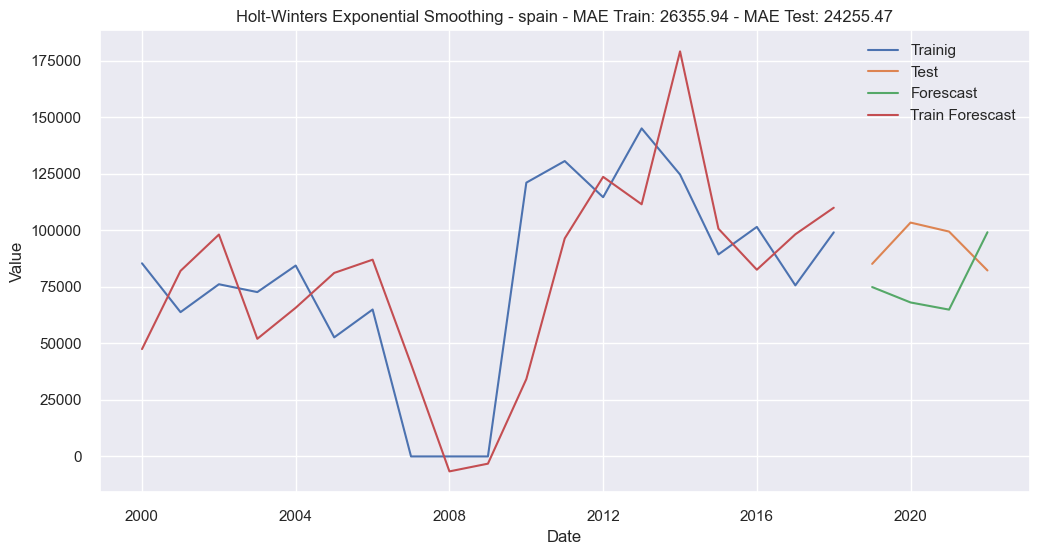

MAE Train: 26159.497819774504
MAE Test 26997.13870794428


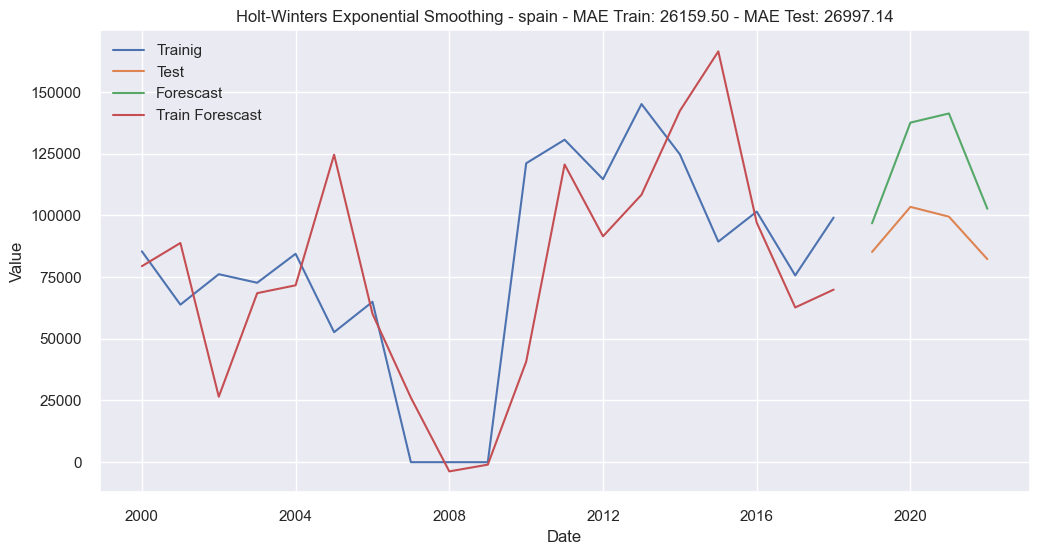

In [333]:
df_metrics = pd.DataFrame(columns=['Country', 'MAE Train', 'MAE Test'])
for country in ['france','italy','türkiye','poland','spain']:
    mae_train0, mae_test0 = test_holt_winters(dfg, country, m = 3)
    mae_train1, mae_test1 = test_holt_winters(dfg, country, m = 4)
    mae_train2, mae_test2 = test_holt_winters(dfg, country, m = 5)
    
    df_metrics = pd.concat([df_metrics, pd.DataFrame([[country, mae_train0, mae_test0]], columns=['Country', 'MAE Train', 'MAE Test'])])
    df_metrics = pd.concat([df_metrics, pd.DataFrame([[country, mae_train1, mae_test1]], columns=['Country', 'MAE Train', 'MAE Test'])])
    df_metrics = pd.concat([df_metrics, pd.DataFrame([[country, mae_train2, mae_test2]], columns=['Country', 'MAE Train', 'MAE Test'])])
    

In [334]:
df_metrics

,Country,MAE Train,MAE Test
0,france,64866.455601,67318.374804
0,france,58797.418963,78302.155678
0,france,54868.444085,62295.650981
0,italy,24940.637758,14338.439527
0,italy,23223.391042,23442.344007
0,italy,28429.786517,35273.104739
0,türkiye,50678.809649,28479.787681
0,türkiye,48950.749951,47409.942046
0,türkiye,56745.195199,36105.270715
0,poland,22900.746655,10550.195940


As can be seen, the MAE can be reduced based on the iteration of different usage periods; however, there is no strict one where it is reduced. But unlike the other Series models, it is the one that can best approximate, without the need for a complex model.

## Conclusion

As final conclusions, around 20 models have been developed based on the need and the necessary metrics. Where for this work 2 formulations have been selected. The first will be the grouping formulation (3 groups) based on the production of the last 3 years, forecasting using LightGBM and Extra Trees as Regression, and the Holt-Winters model, to have an approximation of the forecast by country.